#  EC1B1 Group Project

**Members: Ian Ng Sheen-Jie, Ong Sze-Hon, Joshua Andrew**


### Overview

This notebook replicates key findings from Itskhoki & Mukhin (2021) for Germany,
studying whether exchange rate volatility affects macroeconomic volatility.
The end of the Bretton Woods system in the early 1970s provides a natural
experiment where exchange rates shifted abruptly from fixed to floating, while
other economic conditions evolved more gradually.

We first clean and construct variables from IMF IFS data (Sections 1-3),
then analyse volatility before and after Bretton Woods (Section 4), and
finally extend the analysis to exchange rate levels and the UK's ERM
experience (Section 5).

### Data Sources

All data is from the [IMF International Financial Statistics](https://data.imf.org/):

| File | Series | Description |
|------|--------|-------------|
| `ER_Germany.csv` | Exchange rate, DEM per USD | Period average, monthly |
| `CPI_Germany.csv` | Consumer Price Index, Germany | Index, monthly |
| `PI_Germany.csv` | Industrial Production, Germany | Index, monthly |
| `IL_Germany.csv` | Total reserves (gold at national value), Germany | USD millions, monthly |
| `CPI_US.csv` | Consumer Price Index, US | Index, monthly |
| `IL_US.csv` | Total reserves (gold at national value), US | USD millions, monthly |
| `ER_UK.csv` | Exchange rate, GBP per USD | For Section 5.2 |
| `CPI_UK.csv` | Consumer Price Index, UK | For Section 5.2 |
| `PI_UK.csv` | Industrial Production, UK | For Section 5.2 |
| `IL_UK.csv` | Total reserves (gold at national value), UK | For Section 5.2 |


## 1. Loading Data

In [1]:
# Ensure required packages are available (standard in Colab, listed for reproducibility)
# !pip install pandas matplotlib numpy scipy --quiet

# Mount Google Drive so we can access the shared project folder
from google.colab import drive
drive.mount('/content/drive')

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates    # date formatting on plot axes
from scipy import stats              # for linregress in Section 4.4
from matplotlib.lines import Line2D
import os
import warnings
# Suppress matplotlib font-fallback warnings that clutter output
# but do not affect results. All other warnings are left active.
# We target only matplotlib warnings rather than suppressing all warnings,
# so that genuine data issues (e.g. NaN in a merge) are still surfaced.
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

Mounted at /content/drive


<div style="background-color:#FFF3CD; border-left:6px solid #FFC107; padding:16px 20px; border-radius:6px; margin:10px 0;">

**⚠️ Before running this notebook, each group member must do this once:**

Google Colab mounts only **My Drive**. Folders in "Shared with me" are not visible.
To make the shared project folder accessible, add a **shortcut**:

1. Open [Google Drive](https://drive.google.com) in your browser.
2. Click **"Shared with me"** in the left sidebar.
3. Find the folder **"EC1B1 Group Project"** (or open [this link](https://drive.google.com/drive/folders/1hvKaXsbFs2Yb4mPxNCtXwHDO7FbpEg0i)).
4. **Right-click** the folder → select **"Organise"** → **"Add shortcut"**.
5. Choose **"My Drive"** as the destination → click **"Add"**.

The shortcut does not copy files. It makes the shared folder visible at
`/content/drive/MyDrive/EC1B1 Group Project/` when your Drive is mounted.
</div>

In [2]:
# Path to the shared project folder (via Drive shortcut)
FOLDER = '/content/drive/MyDrive/EC1B1 Group Project/'

# Verify the folder is accessible before proceeding
try:
    files = os.listdir(FOLDER)
    print('✅ Folder accessible. Contents:', sorted(files))
except FileNotFoundError:
    raise FileNotFoundError(
        f'Folder not found at: {FOLDER}\n'
        'Have you added the shared folder shortcut to your Drive? '
        'See the instructions above.'
    )

✅ Folder accessible. Contents: ['CPI_Germany.csv', 'CPI_UK.csv', 'CPI_US.csv', 'ER_Germany.csv', 'ER_UK.csv', 'IL_Germany.csv', 'IL_UK.csv', 'IL_US.csv', 'PI_Germany.csv', 'PI_UK.csv']


## 2. Cleaning Data

The IMF IFS exports contain annual, quarterly, and monthly rows in a single
CSV. We need to filter to monthly frequency and restrict to our study period
(December 1959 to December 1990). December 1959 is included so that
percentage-change calculations for January 1960 have a base month.

In [3]:
# ─── Show the raw IMF data format ───
# We display the raw CSV structure so the raw structure is visible before cleaning
# This makes the subsequent
# filtering and parsing steps transparent rather than hidden.
print("── Raw IMF format (example: ER_Germany.csv) ──\n")
raw_example = pd.read_csv(FOLDER + 'ER_Germany.csv')
print(raw_example.head(3).to_string(index=False))
print(f"\nContains {raw_example['FREQUENCY'].value_counts().to_dict()} (we keep Monthly only).\n")

# ─── Study period bounds ───
# Dec 1959 is included as a base month so Jan 1960 growth rates can be computed.
STUDY_START = '1959-12-01'
STUDY_END   = '1990-12-01'

def load_imf(path, value_col_name):
    """
    Load an IMF IFS CSV, filter to monthly, and restrict to the study period.

    Steps:
      1. Read the raw CSV (contains Annual, Quarterly, Monthly rows).
      2. Keep only Monthly frequency.
      3. Parse TIME_PERIOD (e.g. '1960-M01') into a datetime using pd.to_datetime,
         which wraps Python's datetime module internally.
      4. Filter to STUDY_START – STUDY_END.
      5. Return a clean two-column DataFrame: [date, value].
    """
    raw = pd.read_csv(path)
    monthly = raw[raw['FREQUENCY'] == 'Monthly'].copy()
    monthly['date'] = pd.to_datetime(
        monthly['TIME_PERIOD'].str.replace('-M', '-', regex=False), format='%Y-%m')
    # errors='coerce' converts any non-numeric entries to NaN rather than
    # crashing. a defensive choice since IMF exports occasionally contain
    # footnote markers or missing-value codes in the OBS_VALUE column.
    monthly[value_col_name] = pd.to_numeric(monthly['OBS_VALUE'], errors='coerce')

    # Restrict to study period
    study = (monthly[['date', value_col_name]]
             .loc[(monthly['date'] >= STUDY_START) & (monthly['date'] <= STUDY_END)]
             .sort_values('date')
             .reset_index(drop=True))

    # Print cleaning summary
    fname = path.split('/')[-1]
    print(f"  {fname:25s} │ {len(raw):5d} raw → {len(monthly):4d} monthly → {len(study):3d} in study period"
          f" │ {study['date'].min():%Y-%m} to {study['date'].max():%Y-%m}")
    return study


# ─── Load and clean each series ───
# We use a reusable function (load_imf) rather than repeating the same
# cleaning logic six times. This ensures all series are cleaned identically
# and makes the pipeline easier to audit. any change to the cleaning
# logic only needs to be made once.
print("── Cleaning pipeline ──\n")
print(f"  {'File':<25s} │ {'Pipeline':^40s} │ Date range")
print(f"  {'─'*25} │ {'─'*40} │ {'─'*20}")

pi_de  = load_imf(FOLDER + 'PI_Germany.csv',  'ip_de')     # Industrial Production index
er_de  = load_imf(FOLDER + 'ER_Germany.csv',  'e_nom')     # DEM per USD, period average
cpi_de = load_imf(FOLDER + 'CPI_Germany.csv', 'cpi_de')    # CPI index, Germany
cpi_us = load_imf(FOLDER + 'CPI_US.csv',      'cpi_us')    # CPI index, US
il_de  = load_imf(FOLDER + 'IL_Germany.csv',  'res_de')    # Total reserves, USD millions
il_us  = load_imf(FOLDER + 'IL_US.csv',       'res_us')    # Total reserves, USD millions

── Raw IMF format (example: ER_Germany.csv) ──

COUNTRY                       INDICATOR TYPE_OF_TRANSFORMATION FREQUENCY TIME_PERIOD  OBS_VALUE SCALE
Germany Domestic currency per US Dollar         Period average Quarterly     1957-Q1        4.2 Units
Germany Domestic currency per US Dollar         Period average Quarterly     1957-Q2        4.2 Units
Germany Domestic currency per US Dollar         Period average Quarterly     1957-Q3        4.2 Units

Contains {'Monthly': 504, 'Quarterly': 168, 'Annual': 49} (we keep Monthly only).

── Cleaning pipeline ──

  File                      │                 Pipeline                 │ Date range
  ───────────────────────── │ ──────────────────────────────────────── │ ────────────────────
  PI_Germany.csv            │  1153 raw →  815 monthly → 373 in study period │ 1959-12 to 1990-12
  ER_Germany.csv            │   721 raw →  504 monthly → 373 in study period │ 1959-12 to 1990-12
  CPI_Germany.csv           │  1208 raw →  853 monthly → 373 

In [4]:
# Merge all six series into a single DataFrame, aligned by date.
# We use how='outer' so that no months are dropped if one series has a gap;
# any such gaps would show up as NaN and be caught by the missing-value check.
# Since each series was already filtered to the same study period above,
# the outer join is equivalent to an inner join here. all 373 dates match.
df = (pi_de
      .merge(er_de,  on='date', how='outer')
      .merge(cpi_de, on='date', how='outer')
      .merge(cpi_us, on='date', how='outer')
      .merge(il_de,  on='date', how='outer')
      .merge(il_us,  on='date', how='outer')
      .sort_values('date')
      .reset_index(drop=True))

print(f'Merged: {len(df)} rows × {df.shape[1]} columns')
print(f'Range:  {df["date"].min():%Y-%m} to {df["date"].max():%Y-%m}')
# Printing missing values immediately after merging catches any alignment
# issues. if a series had fewer months than expected, NaNs would appear here.
print(f'\nMissing values:\n{df.isnull().sum()}')

Merged: 373 rows × 7 columns
Range:  1959-12 to 1990-12

Missing values:
date      0
ip_de     0
e_nom     0
cpi_de    0
cpi_us    0
res_de    0
res_us    0
dtype: int64


We now have 373 monthly observations (Dec 1959 to Dec 1990) across six raw
variables. The next step is to construct the derived variables required by
the coursework (Section 3.2) which are the growth rates, a real exchange rate, and index
series.

### Variable Construction

The **nominal exchange rate** `e_nom` is **DEM per USD** (IMF, period average).
A rise in `e_nom` means more DEM are needed per dollar (a DEM **depreciation**).

The **real exchange rate** follows the Lecture 4 definition (W4, slide 6):

$$\varepsilon = E \times \frac{P_{US}}{P_{DE}}$$

where $E$ is DEM/USD, $P_{US}$ is the US CPI, and $P_{DE}$ is the German CPI.
This gives the price of US goods in terms of German goods. A higher
$\varepsilon$ means US goods are more expensive (the dollar is stronger in real terms).

**Monthly growth** in the real exchange rate is computed as the percentage change
of $\varepsilon_t$, equivalent to the Lecture 4 approximation (W4, slide 8):
$x \approx \Delta E / E + \pi_{US} - \pi_{DE}$.

The **real exchange rate index** is built from cumulated monthly growth rates,
normalised so that December 1990 = 1 (as required by the coursework).

All growth rates are expressed as **percentage changes** for comparability
across variables (Section 3.2 tip).

In [5]:
# Construct all required variables, following the coursework Section 3.2 order.
# All growth rates are percentage changes (×100) for comparability.

# (i) Monthly growth in the nominal exchange rate (%)
# pct_change() computes (x_t - x_{t-1}) / x_{t-1}. We multiply by 100
# so all growth rates are in percentage points, making them directly
# comparable across variables with different scales (coursework Section 3.2 tip).
df['g_e_nom'] = df['e_nom'].pct_change() * 100

# (ii) Monthly growth in the real exchange rate (%)
# e_nom is DEM per USD. q = e_nom × (CPI_US / CPI_DE) gives the real price
# of one US goods basket in terms of German goods baskets.
df['q'] = df['e_nom'] * (df['cpi_us'] / df['cpi_de'])
df['g_e_real'] = df['q'].pct_change() * 100

# (iii) Index of the real exchange rate (Dec 1990 = 1)
# Built from cumulated monthly growth rates as required by the coursework.
# fillna(0) sets the first month's growth to 0%, so the index starts at 1.
# This is safe because the final normalisation (Dec 1990 = 1) rescales
# everything, so the starting value cancels out.
df['q_index'] = (1 + df['g_e_real'].fillna(0) / 100).cumprod()
q_dec90 = df.loc[df['date'] == '1990-12-01', 'q_index'].values[0]
df['q_index'] = df['q_index'] / q_dec90

# (iv) Monthly inflation rate, Germany (%)
df['inf_de'] = df['cpi_de'].pct_change() * 100

# (v) Monthly growth in industrial production (%)
df['g_ip_m'] = df['ip_de'].pct_change() * 100

# (vi) Growth in industrial production versus 12 months ago (%)
# e.g. Jan 1971 vs Jan 1970
df['g_ip_12m'] = df['ip_de'].pct_change(periods=12) * 100

# (vii) Index of international reserves, Germany (Jan 1960 = 100)
# We index rather than plot raw USD values because Germany and the US
# had very different absolute reserve levels. Indexing to a common base
# makes the *trends* directly comparable on the same axis.
res_de_base = df.loc[df['date'] == '1960-01-01', 'res_de'].values[0]
df['res_de_idx'] = (df['res_de'] / res_de_base) * 100

# US variables (coursework Section 3.2):
# (i) Monthly inflation rate, US (%)
df['inf_us'] = df['cpi_us'].pct_change() * 100

# (ii) Index of international reserves, US (Jan 1960 = 100)
res_us_base = df.loc[df['date'] == '1960-01-01', 'res_us'].values[0]
df['res_us_idx'] = (df['res_us'] / res_us_base) * 100

# Inflation difference: Germany minus US (used in Sections 4.2–4.4).
# This direction follows the coursework wording: "the difference between
# monthly inflation in your country versus the United States."
df['inf_diff'] = df['inf_de'] - df['inf_us']

print('Variables constructed.')
print(f'Columns: {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()}')

Variables constructed.
Columns: ['date', 'ip_de', 'e_nom', 'cpi_de', 'cpi_us', 'res_de', 'res_us', 'g_e_nom', 'q', 'g_e_real', 'q_index', 'inf_de', 'g_ip_m', 'g_ip_12m', 'res_de_idx', 'inf_us', 'res_us_idx', 'inf_diff']

Missing values:
date           0
ip_de          0
e_nom          0
cpi_de         0
cpi_us         0
res_de         0
res_us         0
g_e_nom        1
q              0
g_e_real       1
q_index        0
inf_de         1
g_ip_m         1
g_ip_12m      12
res_de_idx     0
inf_us         1
res_us_idx     0
inf_diff       1
dtype: int64


In [6]:
# ─── Verify: level-based RER growth vs Lecture 4 approximation ───
# Level-based: g_e_real = pct_change of q_t = E_t × P_US,t / P_DE,t
# Approximation: ΔE/E + π_US − π_DE  (W4, slide 8)
approx_g_real = df['g_e_nom'] + df['inf_us'] - df['inf_de']
diff = (df['g_e_real'] - approx_g_real).dropna().abs()   # drop the first-row NaN
print(f'Observations compared: {len(diff)}')
print(f'Max absolute difference: {diff.max():.4f} pp')
print(f'Mean absolute difference: {diff.mean():.5f} pp')
assert diff.max() < 0.15, f'Methods diverge by {diff.max():.4f}pp; check formula'

Observations compared: 372
Max absolute difference: 0.0984 pp
Mean absolute difference: 0.00568 pp


We computed the real exchange rate as a *level* ($q_t$) first, then took
its percentage change, rather than applying the Lecture 4 approximation
($\Delta E/E + \pi_{US} - \pi_{DE}$) directly. Both approaches give
nearly identical results for small monthly changes, but working from the
level avoids the approximation error that compounds over 30 years of
data. We verified this in the cell above that the mean divergence is
under 0.006pp across all 372 months. The index in (iii) must be built from the level
anyway, so computing $q_t$ first keeps the code consistent.

### Data Validation

In [7]:
# Verify key values against known German exchange rate history.
# Validation against external facts (not just internal consistency)
# catches errors that internal checks miss. e.g. if we accidentally
# loaded quarterly instead of monthly data, the row count might look
# fine but the DEM/USD rate at specific dates would be wrong.
print('=== Exchange Rate ===')
print(f'DEM/USD Dec 1959: {df.loc[df["date"]=="1959-12-01","e_nom"].values[0]:.2f}  (expected: 4.20)')
print(f'DEM/USD Dec 1990: {df.loc[df["date"]=="1990-12-01","e_nom"].values[0]:.3f}  (expected: ~1.49)')

# The DEM was revalued in March 1961 from 4.20 to 4.00. a known historical event.
# If this doesn't show up, the exchange rate data is wrong.
feb61 = df.loc[df['date']=='1961-02-01','e_nom'].values[0]
mar61 = df.loc[df['date']=='1961-03-01','e_nom'].values[0]
print(f'Revaluation Mar 1961: {feb61:.2f} → {mar61:.2f} ({(mar61/feb61-1)*100:+.1f}%)')

# The RER index must equal exactly 1.0 at the normalisation point.
print(f'\n=== Real Exchange Rate Index ===')
print(f'Dec 1990 = {df.loc[df["date"]=="1990-12-01","q_index"].values[0]:.4f}  (must be 1.0)')

# Reserves base values. used to compute indices.
print(f'\n=== Reserves (base for index) ===')
print(f'Germany Jan 1960: {df.loc[df["date"]=="1960-01-01","res_de"].values[0]:,.0f}m USD')
print(f'US Jan 1960:      {df.loc[df["date"]=="1960-01-01","res_us"].values[0]:,.0f}m USD')

=== Exchange Rate ===
DEM/USD Dec 1959: 4.20  (expected: 4.20)
DEM/USD Dec 1990: 1.492  (expected: ~1.49)
Revaluation Mar 1961: 4.20 → 4.00 (-4.8%)

=== Real Exchange Rate Index ===
Dec 1990 = 1.0000  (must be 1.0)

=== Reserves (base for index) ===
Germany Jan 1960: 4,724m USD
US Jan 1960:      21,478m USD


If any of these checks had failed, we would have re-examined the raw CSV
to determine whether the issue was a download error, a parsing mistake
(e.g. loading quarterly data instead of monthly), or a genuine data gap.
All checks passed, so we proceed with confidence that the cleaning pipeline
produced the correct values. The DEM/USD rate matches the known 4.20 starting value, the March 1961 revaluation is visible, and the RER index equals exactly 1.0 at its normalisation point.

## 3. End Product

In [8]:
# Display the full merged dataset as required by the coursework (Section 3.3).
# We use display() rather than print() because it renders the DataFrame
# as a formatted HTML table in Colab, with aligned columns and proper
# handling of NaN values. Temporarily increase max_rows so all 373 rows
# are visible (pandas defaults to showing only 60), then reset so that
# subsequent DataFrames in the notebook don't flood the output.
pd.options.display.max_rows = 400
display(df)
pd.options.display.max_rows = 60

,date,ip_de,e_nom,cpi_de,cpi_us,res_de,res_us,g_e_nom,q,g_e_real,q_index,inf_de,g_ip_m,g_ip_12m,res_de_idx,inf_us,res_us_idx,inf_diff
0,1959-12-01,32.500305,4.200000,21.78135,13.482806,4811.474341,21504.500000,NaN,2.599829,NaN,1.713301,NaN,NaN,NaN,101.848342,NaN,100.122916,NaN
1,1960-01-01,31.193881,4.200000,21.78135,13.436946,4724.155785,21478.100000,0.000000e+00,2.590986,-0.340136,1.707474,0.000000,-4.019729,NaN,100.000000,-0.340136,100.000000,0.340136
2,1960-02-01,31.041599,4.200000,21.65760,13.482806,4806.362830,21395.700000,0.000000e+00,2.614684,0.914640,1.723091,-0.568147,-0.488181,NaN,101.740143,0.341297,99.616353,-0.909444
3,1960-03-01,32.203755,4.200000,21.65760,13.482806,4966.456016,21344.700000,0.000000e+00,2.614684,0.000000,1.723091,0.000000,3.743868,NaN,105.128964,0.000000,99.378902,0.000000
4,1960-04-01,34.287622,4.200000,21.78135,13.528666,5236.120624,21278.000000,0.000000e+00,2.608672,-0.229943,1.719129,0.571393,6.470881,NaN,110.837171,0.340136,99.068353,0.231257
5,1960-05-01,33.726581,4.200000,21.84323,13.528666,5417.091847,21234.300000,0.000000e+00,2.601282,-0.283291,1.714259,0.284096,-1.636279,NaN,114.667934,0.000000,98.864890,0.284096
6,1960-06-01,34.399830,4.200000,21.84323,13.574526,5843.766907,21169.800000,0.000000e+00,2.610100,0.338983,1.720070,0.000000,1.996198,NaN,123.699708,0.338983,98.564584,-0.338983
7,1960-07-01,32.348023,4.200000,21.84323,13.574526,6124.728538,20999.400000,0.000000e+00,2.610100,0.000000,1.720070,0.000000,-5.964585,NaN,129.647048,0.000000,97.771218,0.000000
8,1960-08-01,31.153807,4.200000,21.84323,13.574526,6358.680576,20803.400000,0.000000e+00,2.610100,0.000000,1.720070,0.000000,-3.691774,NaN,134.599299,0.000000,96.858661,0.000000
9,1960-09-01,34.656306,4.200000,21.78135,13.574526,6643.272902,20430.000000,0.000000e+00,2.617515,0.284096,1.724956,-0.283291,11.242604,NaN,140.623493,0.000000,95.120146,-0.283291


## 4. Analysis and Questions

The analysis below follows the structure of the coursework. For all
time-series graphs, we mark when Germany departed from Bretton Woods
so it is clear whether volatility changed. The exact dates are in comments in the code below.

In [9]:
# ─── Plotting defaults ───
# Following Schwabish (2014): show the data, reduce clutter, integrate text.
# Following EC1B1 Presentation Guidance: titles state findings, not descriptions.
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,       # remove top spine (Schwabish: reduce clutter)
    'axes.spines.right': False,     # remove right spine
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'font.family': 'serif',
    'axes.grid': True,              # light gridlines for readability
    'grid.alpha': 0.12,
    'grid.linewidth': 0.4,
})

# ─── Colour palette ───
# Blue for Bretton Woods (fixed) era, red for floating era, grey for transition.
# Using distinct colours makes the regime change visible at a glance.
C_PRE   = '#2166ac'   # blue, Bretton Woods era
C_POST  = '#b2182b'   # red, floating era
C_TRANS = '#999999'   # grey, transition period (Jul 1971 to Feb 1973)
C_DE    = '#2166ac'   # Germany series
C_US    = '#d6604d'   # United States series

# ─── Key dates for Germany ───
# Germany's departure from Bretton Woods was a two-step process, not a
# single event. We mark both steps so the transition is visible.
NIXON_SHOCK  = pd.Timestamp('1971-08-15')   # US suspends gold convertibility
DE_FLOAT_MAY = pd.Timestamp('1971-05-01')   # DEM temporarily floated (before Nixon Shock)
DE_FLOAT_MAR = pd.Timestamp('1973-03-01')   # formal move to floating after Smithsonian collapse

# ─── Plotting subset ───
# Drop Dec 1959 (only used for computing Jan 1960 growth rates)
plot_df = df[df['date'] >= '1960-01-01'].copy()


def add_bw_markers(ax):
    """
    Mark the Bretton Woods transition on a time-series plot:
    - Grey shaded band over the transition period (May 1971 – Feb 1973)
    - Dotted line at May 1971 (DEM floated)
    - Dashed line at March 1973 (formal float)
    Returns line handles for use in figure-level legends.
    """
    ax.axvspan(pd.Timestamp('1971-05-01'), pd.Timestamp('1973-02-28'),
               alpha=0.06, color='grey', zorder=0)
    # Dotted for May 1971 (temporary, tentative float) vs dashed for
    # March 1973 (permanent, formal float). the visual weight reflects
    # the significance of each event.
    l1 = ax.axvline(DE_FLOAT_MAY, color='#888', linestyle=':', linewidth=0.8,
                     alpha=0.7, zorder=1, label='DEM floated (May 1971)')
    l2 = ax.axvline(DE_FLOAT_MAR, color='#888', linestyle='--', linewidth=0.8,
                     alpha=0.7, zorder=1, label='Formal float (Mar 1973)')
    return l1, l2

### 4.1 Exchange Rate and International Reserve Graphs

We use line charts for growth rates, coloured by regime period (blue for
Bretton Woods, grey for the transition, red for the floating era). With
372 monthly observations, bar charts merge into a solid mass at subplot
scale; line segments preserve individual months and make discrete events
visible. Level and index series use standard line charts.

**Why does Germany show FX movement during the Bretton Woods period?**
Unlike the United States, which maintained a fully fixed dollar–gold rate
until August 1971, Germany adjusted its peg against the dollar twice during Bretton Woods,
and temporarily floated the DEM in May 1971:

- **March 1961:** DEM revalued from 4.20 to 4.00 per USD (−4.8%), visible
  as a sharp downward spike in the nominal growth panel.
- **October 1969:** DEM revalued from 4.00 to approximately 3.66 (−8.5%),
  the largest single-month move in the pre-float era.
- **May 1971:** Germany temporarily floated the DEM, three months before the
  Nixon Shock. This was triggered by speculative capital inflows as markets
  anticipated a broader collapse of the fixed rate system (W4, slide 18).

These adjustments explain why Germany's pre-BW nominal FX standard deviation
(0.87%) is not zero as the peg was periodically adjusted under pressure from
persistent German trade surpluses and inflation differentials (π_US > π_DE).
The Itskhoki & Mukhin (2021) US data shows an even starker contrast (pre-BW
SD near zero) precisely because the US never revalued; it simply abandoned
gold convertibility outright. Germany's 3× volatility increase at the BW
break (versus roughly 5× for the US) partly reflects these prior adjustments
having already introduced some FX variation into the pre-BW sample.

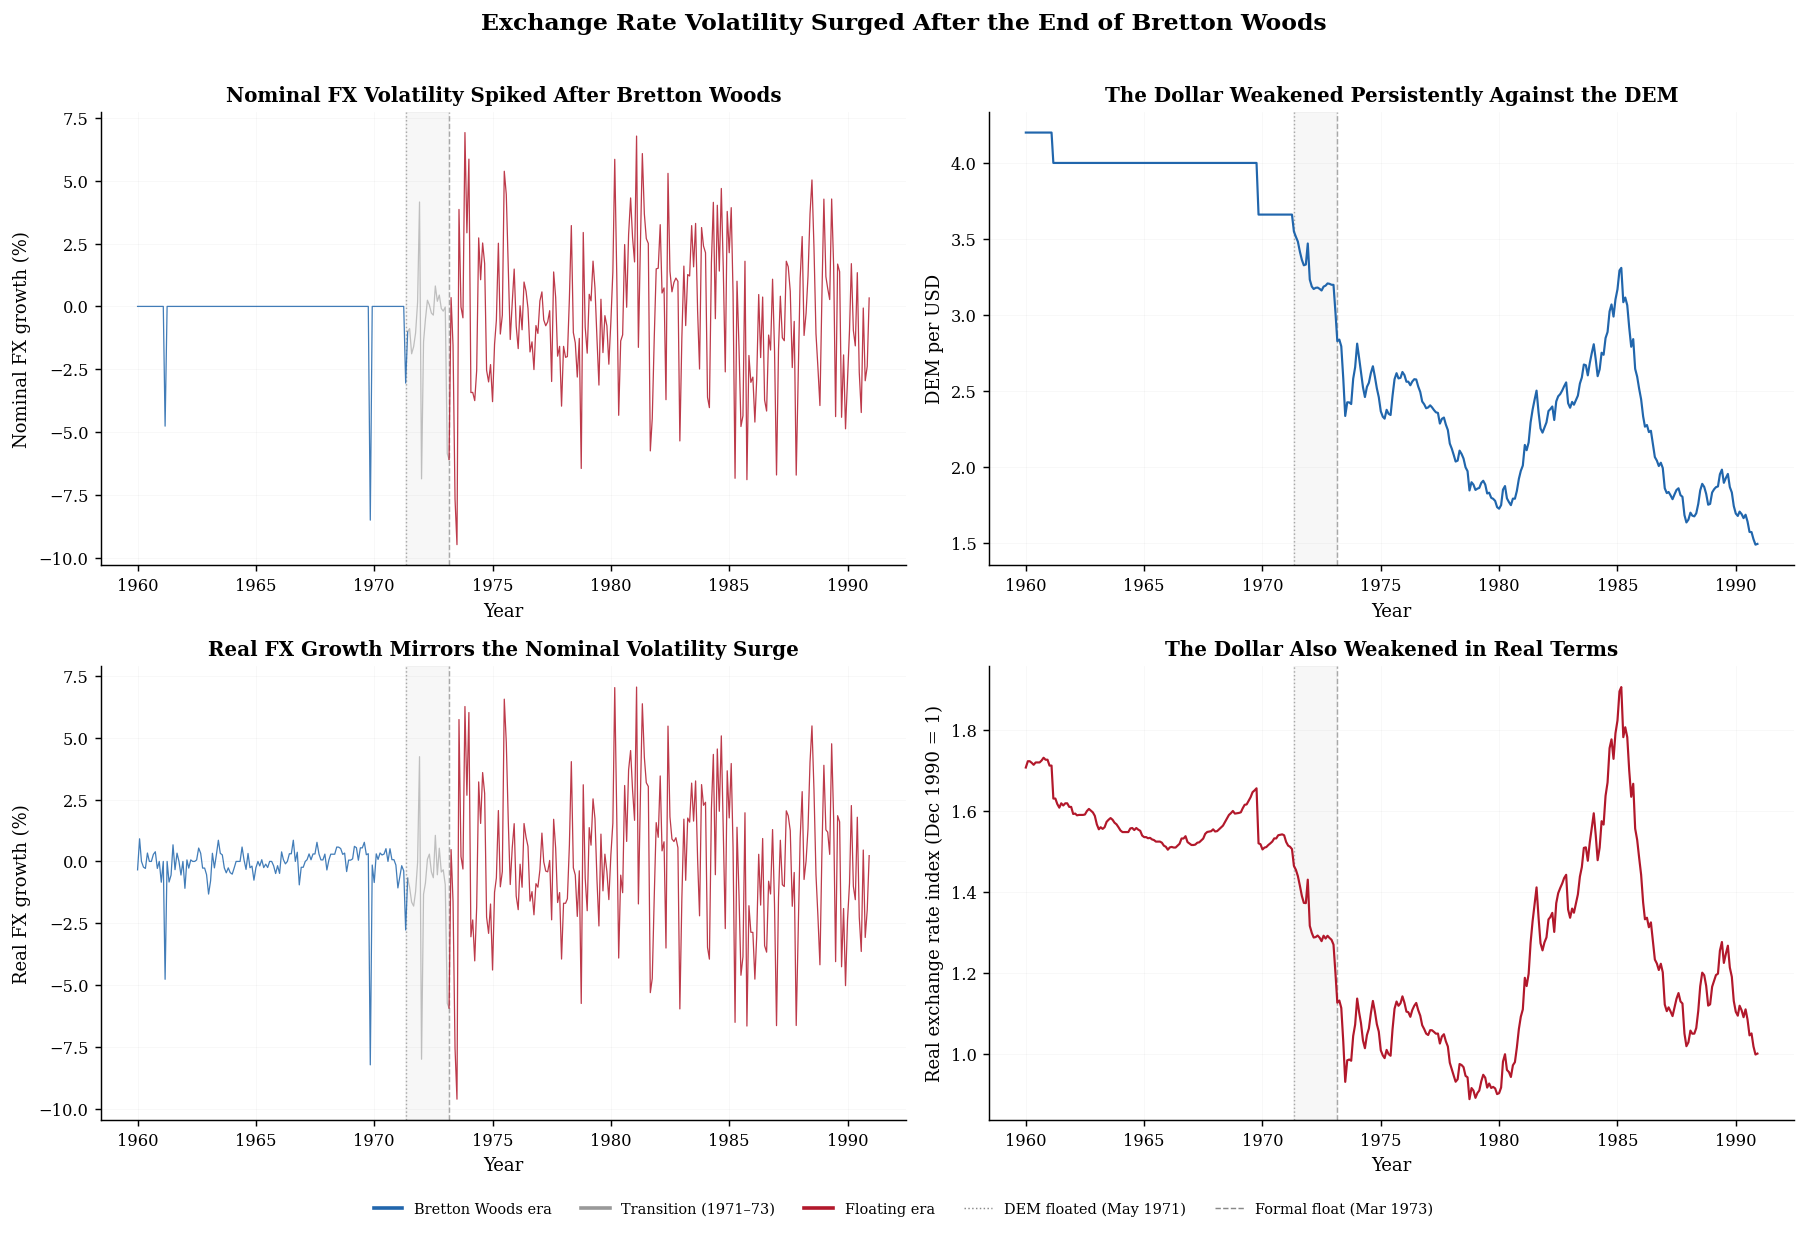

In [10]:
# The coursework asks to "find an attractive way to present the four graphs
# together." A 2×2 grid groups growth rates (left) alongside levels (right),
# and nominal (top) alongside real (bottom), so both dimensions are comparable
#
# We use line charts (not bars) for growth rates. With 372 monthly observations,
# bars merge into a solid mass at this subplot scale. Coloured line segments
# make individual months recoverable and show Germany's discrete BW-era
# revaluations (1961, 1969, 1971) as sharp spikes rather than hidden bars.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Exchange Rate Volatility Surged After the End of Bretton Woods',
             fontsize=13, fontweight='bold', y=1.01)

# ─── Regime sub-periods for colour-coded line segments ───
pre   = plot_df[plot_df['date'] <= '1971-06-01']
trans = plot_df[(plot_df['date'] >= '1971-06-01') & (plot_df['date'] <= '1973-03-01')]
post  = plot_df[plot_df['date'] >= '1973-03-01']

# (a) Monthly growth in nominal exchange rate. regime-coloured lines
ax = axes[0, 0]
ax.plot(pre['date'],   pre['g_e_nom'],   color=C_PRE,   linewidth=0.7, alpha=0.85, label='Bretton Woods era')
ax.plot(trans['date'], trans['g_e_nom'], color=C_TRANS, linewidth=0.7, alpha=0.6,  label='Transition (1971–73)')
ax.plot(post['date'],  post['g_e_nom'],  color=C_POST,  linewidth=0.7, alpha=0.85, label='Floating era')
add_bw_markers(ax)
ax.set_title('Nominal FX Volatility Spiked After Bretton Woods')
ax.set_ylabel('Nominal FX growth (%)')

# (b) Level of nominal exchange rate. single series with BW markers
ax = axes[0, 1]
ax.plot(plot_df['date'], plot_df['e_nom'], color=C_DE, linewidth=1.2)
l1, l2 = add_bw_markers(ax)
ax.set_title('The Dollar Weakened Persistently Against the DEM')
ax.set_ylabel('DEM per USD')

# (c) Monthly growth in real exchange rate. regime-coloured lines
ax = axes[1, 0]
ax.plot(pre['date'],   pre['g_e_real'],   color=C_PRE,   linewidth=0.7, alpha=0.85)
ax.plot(trans['date'], trans['g_e_real'], color=C_TRANS, linewidth=0.7, alpha=0.6)
ax.plot(post['date'],  post['g_e_real'],  color=C_POST,  linewidth=0.7, alpha=0.85)
add_bw_markers(ax)
ax.set_title('Real FX Growth Mirrors the Nominal Volatility Surge')
ax.set_ylabel('Real FX growth (%)')

# (d) Real exchange rate index. single series with BW markers
ax = axes[1, 1]
ax.plot(plot_df['date'], plot_df['q_index'], color=C_POST, linewidth=1.2)
l1, l2 = add_bw_markers(ax)
ax.set_title('The Dollar Also Weakened in Real Terms')
ax.set_ylabel('Real exchange rate index (Dec 1990 = 1)')

# Shared formatting
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
for ax in axes.flat:
    ax.set_xlabel('Year')

# Shared legend for regime colours + BW markers (applies to growth rate panels).
regime_handles = [
    Line2D([0], [0], color=C_PRE,   linewidth=2, label='Bretton Woods era'),
    Line2D([0], [0], color=C_TRANS, linewidth=2, label='Transition (1971–73)'),
    Line2D([0], [0], color=C_POST,  linewidth=2, label='Floating era'),
    Line2D([0], [0], color='#888', linewidth=0.8, linestyle=':',  label='DEM floated (May 1971)'),
    Line2D([0], [0], color='#888', linewidth=0.8, linestyle='--', label='Formal float (Mar 1973)'),
]
fig.legend(handles=regime_handles, loc='lower center', ncol=5, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.show()

The reserves comparison is shown as a separate figure rather than
squeezed into the 2x2 grid above. It plots two countries
on the same axis (requiring a legend and annotation), which would be
too cluttered in a small subplot. Giving it a full-width figure lets the
divergence between US and German reserves read clearly.

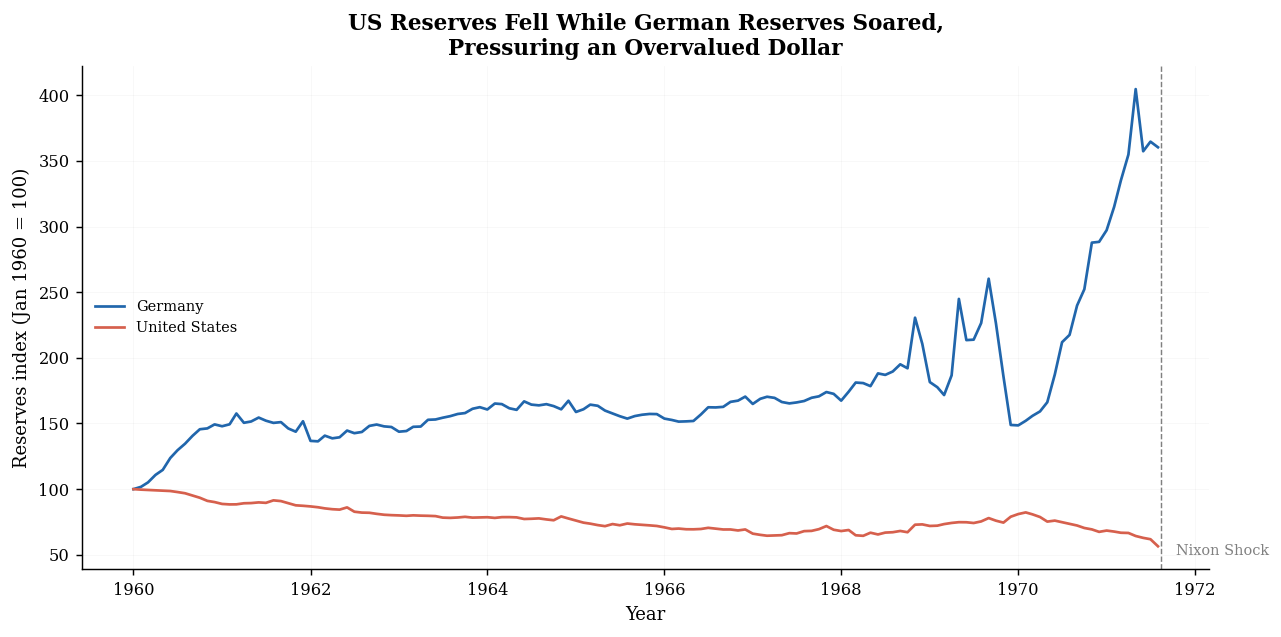

In [11]:
# International reserves index: Germany vs US, Jan 1960 to Nixon Shock.
# Plotting both as indices (Jan 1960 = 100) on the same axis makes the
# divergence in reserve trends immediately visible. raw USD values would
# obscure this because Germany's reserves started much lower than the US's.
# The coursework asks for this to run "until the exit of the US from Bretton Woods."
reserves = plot_df[plot_df['date'] <= NIXON_SHOCK]

fig, ax = plt.subplots(figsize=(10, 5))

# Plot both countries' reserve indices on the same axis for comparison
ax.plot(reserves['date'], reserves['res_de_idx'], color=C_DE, linewidth=1.5,
        label='Germany')
ax.plot(reserves['date'], reserves['res_us_idx'], color=C_US, linewidth=1.5,
        label='United States')

# Mark the Nixon Shock
ax.axvline(NIXON_SHOCK, color='grey', linestyle='--', linewidth=0.8)
ax.annotate('Nixon Shock', xy=(NIXON_SHOCK, 50), fontsize=8, color='grey',
            ha='left', xytext=(8, 0), textcoords='offset points')

ax.set_title('US Reserves Fell While German Reserves Soared,\n'
             'Pressuring an Overvalued Dollar',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Reserves index (Jan 1960 = 100)')
ax.legend(frameon=False, loc='center left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

### 4.1 Questions

**Was the US dollar over- or undervalued in the Bretton Woods system?**

The dollar was **overvalued**. Two pieces of evidence from our graphs
support this.

First, the reserves graph above shows a persistent divergence. By
August 1971, US reserves had fallen to roughly 57% of their January
1960 level, while German reserves had risen to approximately 360%.
Under a fixed exchange rate system, an overvalued currency generates
current account deficits. Exports are too expensive and imports are
cheap, forcing the country to sell reserves to defend the peg. The
diverging reserve paths are a direct signature of this.

Second, the nominal exchange rate graph shows that Germany
**revalued** the DEM against the dollar twice during Bretton
Woods (March 1961: 4.20→4.00; October 1969: 4.00→3.66) and
temporarily floated it in May 1971 (3.66→3.55). These adjustments
were themselves evidence that the
dollar was overvalued. Germany needed to periodically adjust the
peg because rising US inflation ($\pi_{US} > \pi_{DE}$) was making
US goods progressively more expensive in real terms (W4, slide 18).
Under our convention (ε = E × P_US / P_DE), a higher ε means the dollar is stronger in real terms. With a truly fixed nominal rate and US inflation exceeding German inflation, ε would have risen steadily. Each German revaluation lowered E, which pulled ε back down. This is why the real exchange rate index trends downward over the Bretton Woods period, with the revaluations partially correcting the dollar's real overvaluation.

**Using your graphs, explain one reason for the US's departure from
Bretton Woods.**

The reserves graph provides the direct explanation. US reserves
declined persistently as the US sold gold to defend the fixed rate
against persistent current account deficits. By August 1971, the US
gold stock had lost nearly half its value since 1960.
President Nixon suspended dollar convertibility into gold on 15
August 1971 (the "Nixon Shock") because the US could not sustain this
rate of reserve depletion (W4, slide 18; Garber, 1993).

The underlying cause was high US inflation driven by Great Society
spending (W4, slide 17) and the Vietnam War. With $\pi_{US} > \pi_{DE}$
and the nominal rate fixed at the prevailing peg, the dollar was
chronically overvalued, which is consistent with the persistent
reserve outflows shown in the graph above.

### 4.2 Inflation and Industrial Production Graphs

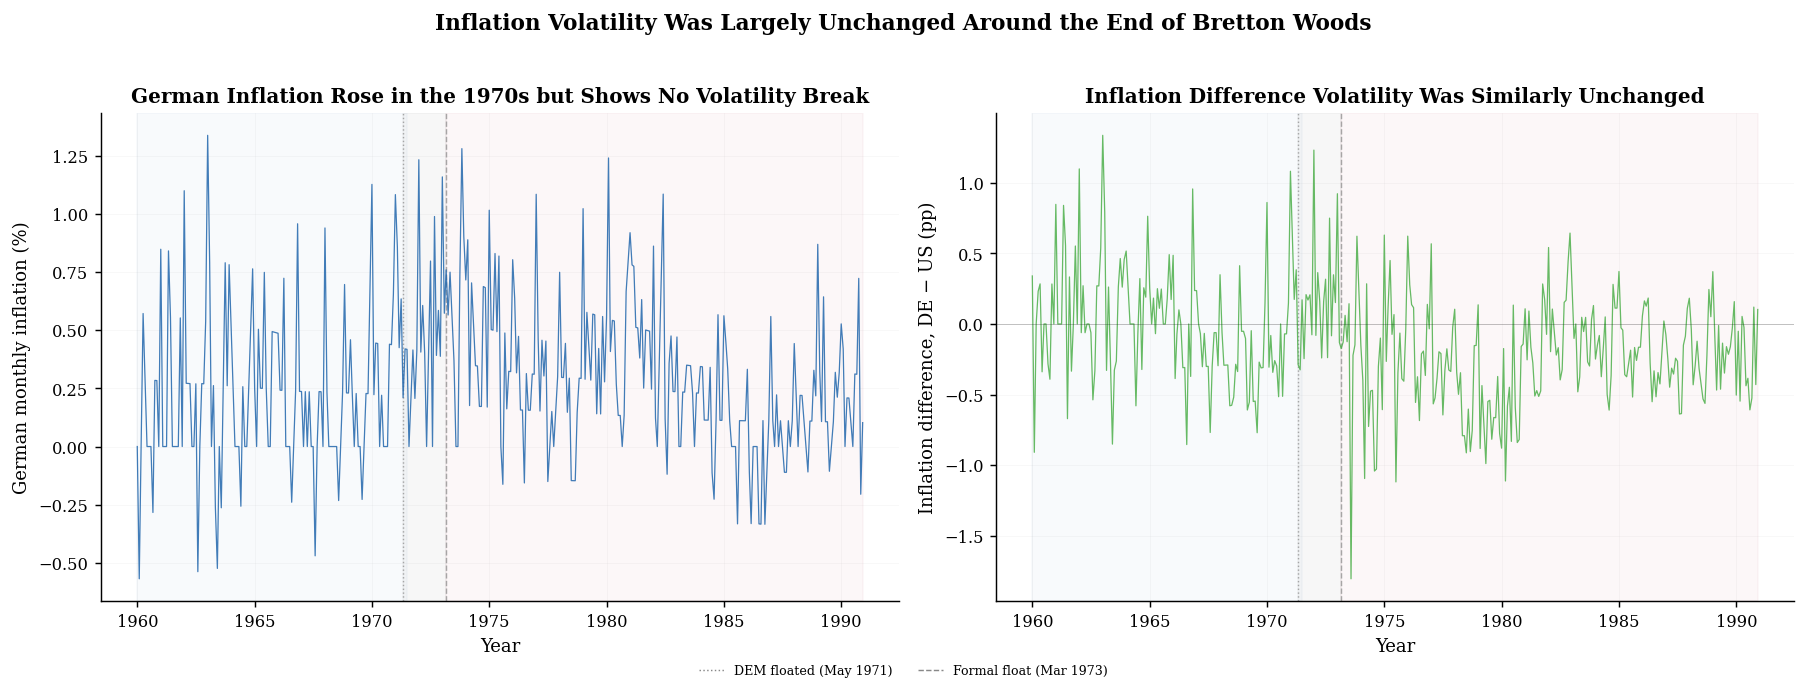

In [12]:
# ─── Inflation graphs (side by side as required) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inflation Volatility Was Largely Unchanged Around the End of Bretton Woods',
             fontsize=12, fontweight='bold', y=1.02)

# Faint background shading reinforces the regime distinction without
# competing with the data itself (alpha=0.03 keeps it subtle).
# We use line charts rather than bars for inflation because inflation
# is a continuous process. unlike FX growth under BW, which was
# genuinely zero most months, making bars the natural choice there.
for ax in axes:
    ax.axvspan(plot_df['date'].min(), pd.Timestamp('1971-06-30'),
               alpha=0.03, color=C_PRE, zorder=0)
    ax.axvspan(pd.Timestamp('1973-03-01'), plot_df['date'].max(),
               alpha=0.03, color=C_POST, zorder=0)

# Left panel: monthly inflation rate for Germany
ax = axes[0]
ax.plot(plot_df['date'], plot_df['inf_de'], color=C_DE, linewidth=0.7, alpha=0.85,
        )
add_bw_markers(ax)
ax.set_title('German Inflation Rose in the 1970s but Shows No Volatility Break')
ax.set_ylabel('German monthly inflation (%)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Right panel: inflation difference (Germany minus US)
ax = axes[1]
ax.plot(plot_df['date'], plot_df['inf_diff'], color='#4daf4a', linewidth=0.7, alpha=0.85,
        )
ax.axhline(0, color='black', linewidth=0.4, alpha=0.3)  # zero reference line
add_bw_markers(ax)
ax.set_title('Inflation Difference Volatility Was Similarly Unchanged')
ax.set_ylabel('Inflation difference, DE − US (pp)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    ax.set_xlabel('Year')

bw_handles = [
    Line2D([0], [0], color='#888', linewidth=0.8, linestyle=':',  label='DEM floated (May 1971)'),
    Line2D([0], [0], color='#888', linewidth=0.8, linestyle='--', label='Formal float (Mar 1973)'),
]
fig.legend(handles=bw_handles, loc='lower center', ncol=2, fontsize=7,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

The inflation graphs show no obvious change in volatility around the
BW break. German inflation rose through the 1970s (driven by the oil
crises), but the *amplitude of fluctuations* looks similar before and
after. The inflation difference oscillates around zero throughout,
with no visible widening after the float.

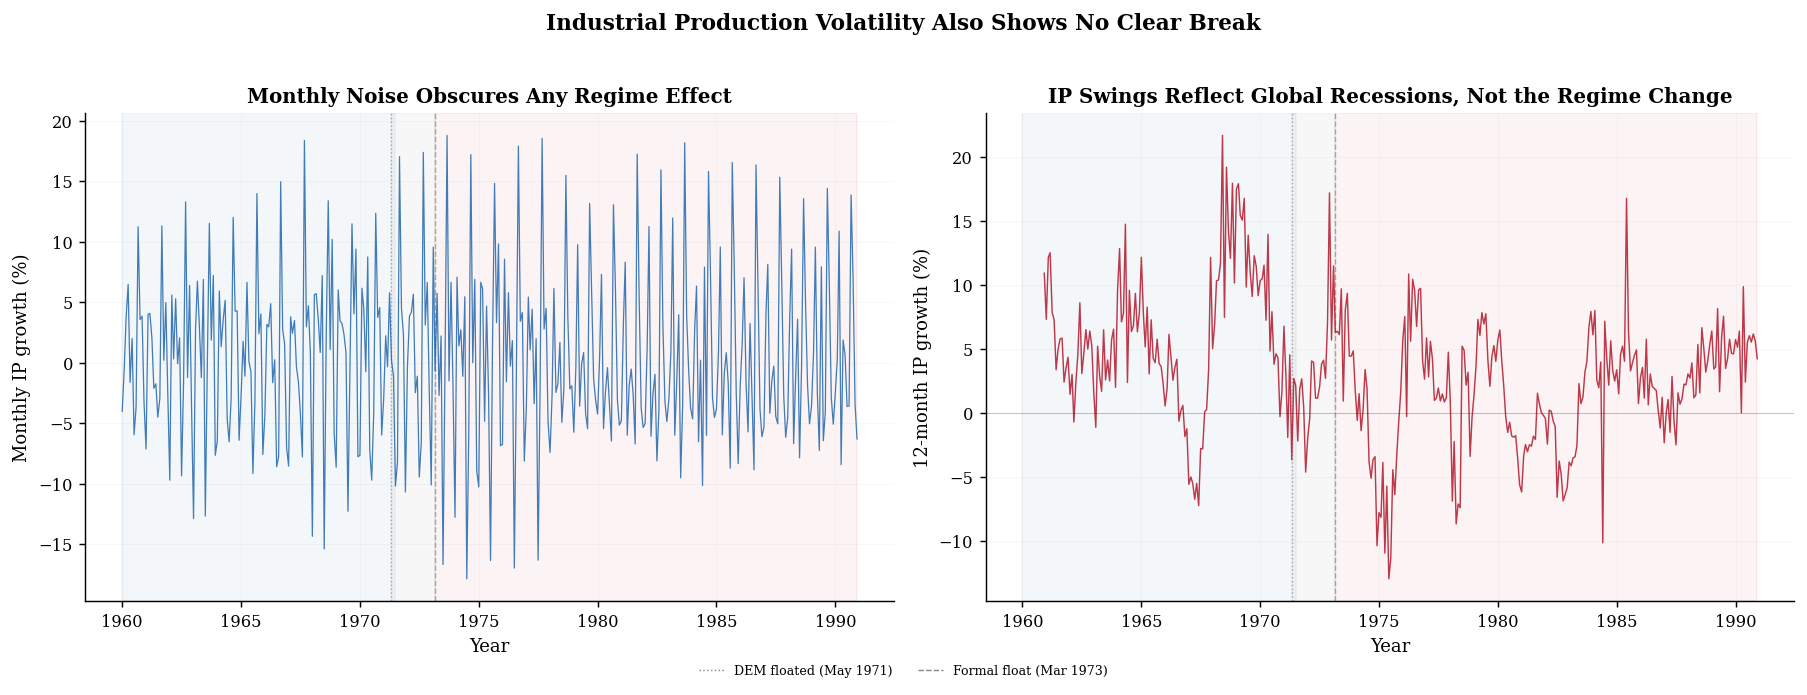

In [13]:
# ─── Industrial production graphs (side by side as required) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Industrial Production Volatility Also Shows No Clear Break',
             fontsize=12, fontweight='bold', y=1.02)

# Faint background shading for regime periods
for ax in axes:
    ax.axvspan(plot_df['date'].min(), pd.Timestamp('1971-06-30'),
               alpha=0.05, color=C_PRE, zorder=0)
    ax.axvspan(pd.Timestamp('1973-03-01'), plot_df['date'].max(),
               alpha=0.05, color=C_POST, zorder=0)

# Left panel: monthly IP growth. expected to be noisy (seasonal effects)
ax = axes[0]
ax.plot(plot_df['date'], plot_df['g_ip_m'], color=C_DE, linewidth=0.7, alpha=0.85,
        )
add_bw_markers(ax)
ax.set_title('Monthly Noise Obscures Any Regime Effect')
ax.set_ylabel('Monthly IP growth (%)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Right panel: 12-month IP growth. smooths out seasonality, reveals business cycle
ax = axes[1]
ax.plot(plot_df['date'], plot_df['g_ip_12m'], color=C_POST, linewidth=0.8, alpha=0.85,
        )
ax.axhline(0, color='black', linewidth=0.4, alpha=0.3)  # zero reference line
add_bw_markers(ax)
ax.set_title('IP Swings Reflect Global Recessions, Not the Regime Change')
ax.set_ylabel('12-month IP growth (%)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    ax.set_xlabel('Year')

bw_handles = [
    Line2D([0], [0], color='#888', linewidth=0.8, linestyle=':',  label='DEM floated (May 1971)'),
    Line2D([0], [0], color='#888', linewidth=0.8, linestyle='--', label='Formal float (Mar 1973)'),
]
fig.legend(handles=bw_handles, loc='lower center', ncol=2, fontsize=7,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

The monthly IP graph (left) is dominated by seasonal noise, making it
hard to see any regime effect. The 12-month measure (right) reveals
clear business-cycle swings, but these appear driven by global events
(the 1974-75 recession, the early 1980s slowdown) rather than by the
exchange rate regime change.

### 4.2 Questions

**Why are monthly vs 12-monthly IP growth results so different? Which
is more useful?**

Monthly industrial production growth is dominated by seasonal effects
and short-term measurement noise. The graph appears as a dense,
high-frequency oscillation with no clear trend visible. The 12-month
measure compares each month to the same month a year earlier, which
naturally eliminates seasonal variation and smooths out measurement
error. The resulting series reveals the underlying business cycle far
more clearly, where recessions such as the mid-1970s oil crisis (where
German IP fell by around 13% year-on-year) are plainly visible.

For our purpose of detecting whether real economic volatility changed
around the end of Bretton Woods, the 12-month measure is more
useful because it isolates meaningful variation in economic activity
from noise that would obscure the comparison.

**Why are we using monthly data?**

The identification strategy relies on the end of Bretton Woods being
a sharp, discrete event. Exchange rate volatility changed "violently
and suddenly" (W4, slide 20) while other macroeconomic factors were
evolving continuously. This discontinuity is the basis for a
regression discontinuity design.

Monthly data serves this strategy in two ways. First, it lets us
precisely date the structural break, rather than blurring it across
quarters or years. Second, it gives us enough observations within
each sub-period to estimate standard deviations reliably (138
observations pre-BW and 214 post-BW). With annual data, we would
have roughly 11 and 18 observations, too few for the standard
deviation of any variable to be estimated with useful precision.
Itskhoki & Mukhin (2021) use monthly series from the IMF IFS for
exactly this reason.

### 4.3 Comparison Statistics & Visualisation

In [14]:
# ─── Define the two regime periods ───
# Pre-BW: Jan 1960 to Jun 1971 (coursework: "include data up to 06/1971")
# Post-BW: Mar 1973 to Dec 1990 (coursework: "only include data from 03/1973")
# Transition (Jul 1971 – Feb 1973) is excluded from both.
pre_bw  = plot_df[plot_df['date'] <= '1971-06-01']
post_bw = plot_df[plot_df['date'] >= '1973-03-01']

# The five variables specified by the coursework (Section 4.3)
variables = {
    'Nominal FX Growth (%)'       : 'g_e_nom',
    'Real FX Growth (%)'          : 'g_e_real',
    'Inflation, Germany (%)'     : 'inf_de',
    'Inflation Diff DE−US (%)'    : 'inf_diff',
    '12-Month IP Growth (%)'      : 'g_ip_12m',
}

# Compute standard deviations for each variable in both periods,
# plus the ratio showing how much volatility changed across regimes.
# A ratio near 1 means the regime change had little effect on that
# variable's volatility; a ratio far from 1 (like ~3× for FX) signals
# a dramatic shift. the core of the Mussa puzzle.
rows = []
for label, col in variables.items():
    sd_pre  = pre_bw[col].std()
    sd_post = post_bw[col].std()
    rows.append({
        'Variable': label,
        'SD Pre-BW (to Jun 1971)': round(sd_pre, 4),
        'SD Post-BW (from Mar 1973)': round(sd_post, 4),
        'Ratio (Post / Pre)': round(sd_post / sd_pre, 2),
    })

std_table = pd.DataFrame(rows).set_index('Variable')
display(std_table)

,SD Pre-BW (to Jun 1971),SD Post-BW (from Mar 1973),Ratio (Post / Pre)
Variable,,,
Nominal FX Growth (%),0.8673,2.8794,3.32
Real FX Growth (%),0.9344,2.9390,3.15
"Inflation, Germany (%)",0.3422,0.3068,0.90
Inflation Diff DE−US (%),0.4146,0.3671,0.89
12-Month IP Growth (%),5.6142,4.6867,0.83


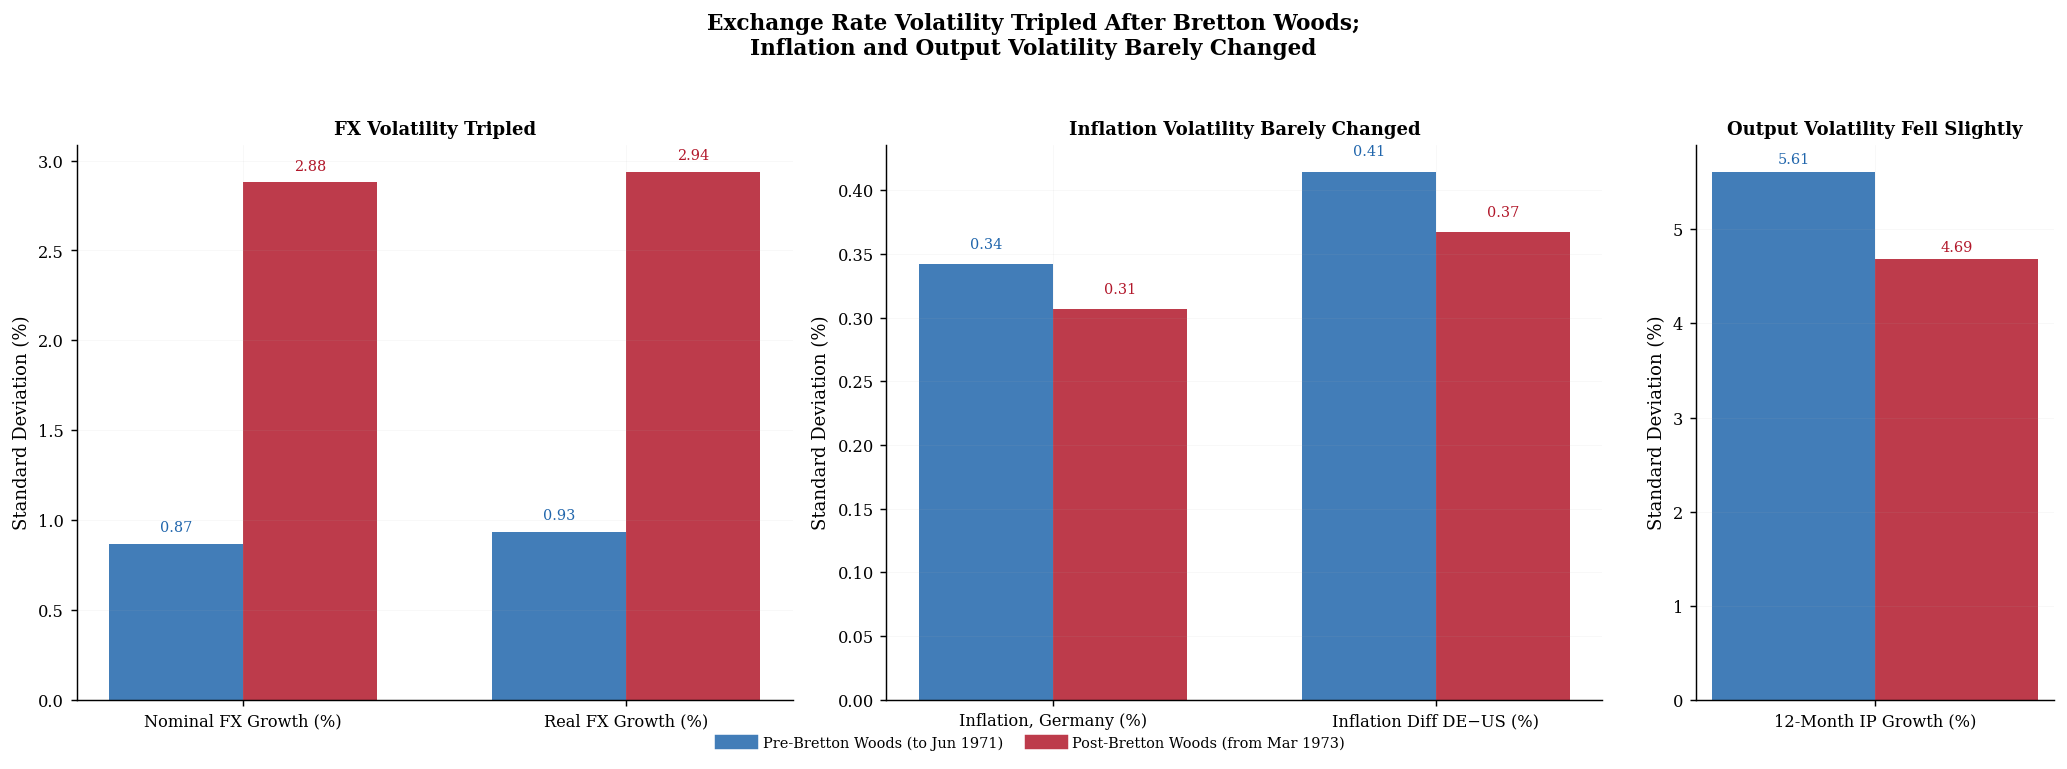

In [15]:
# ─── Standard deviation bar chart ───
# Split into three panels so each group of variables has its own y-axis scale.
# Without this, the inflation SDs (~0.3) would be invisible next to IP (~5).
# Direct labels on bars follow Schwabish (2014): "integrate the text and the graph."
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5.5),
                                     gridspec_kw={'width_ratios': [2, 2, 1]})
# width_ratios=[2, 2, 1] gives the two-variable panels more space than
# the single-variable IP panel, so bar widths are consistent across panels.
fig.suptitle('Exchange Rate Volatility Tripled After Bretton Woods;\n'
             'Inflation and Output Volatility Barely Changed',
             fontsize=12, fontweight='bold', y=1.03)

# Width of each bar in the grouped bar chart
width = 0.35

def add_bar_labels(ax, bars, colour, y_offset):
    """Add value labels directly on top of each bar."""
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + y_offset,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8, color=colour)

# ── Left panel: Exchange rate variables (large SDs, ~0.9 to ~2.9) ──
fx_vars = {k: v for k, v in list(variables.items())[:2]}
x1 = np.arange(len(fx_vars))
pre_fx  = [pre_bw[c].std() for c in fx_vars.values()]
post_fx = [post_bw[c].std() for c in fx_vars.values()]

b1 = ax1.bar(x1 - width/2, pre_fx,  width, color=C_PRE,  alpha=0.85, label='Pre-BW')
b2 = ax1.bar(x1 + width/2, post_fx, width, color=C_POST, alpha=0.85, label='Post-BW')
add_bar_labels(ax1, b1, C_PRE, 0.05)
add_bar_labels(ax1, b2, C_POST, 0.05)
ax1.set_xticks(x1)
ax1.set_xticklabels(list(fx_vars.keys()), fontsize=9)
ax1.set_ylabel('Standard Deviation (%)')
ax1.set_title('FX Volatility Tripled', fontsize=10)

# ── Middle panel: Inflation variables (small SDs, ~0.3 to ~0.4) ──
inf_vars = {k: v for k, v in list(variables.items())[2:4]}
x2 = np.arange(len(inf_vars))
pre_inf  = [pre_bw[c].std() for c in inf_vars.values()]
post_inf = [post_bw[c].std() for c in inf_vars.values()]

b3 = ax2.bar(x2 - width/2, pre_inf,  width, color=C_PRE,  alpha=0.85)
b4 = ax2.bar(x2 + width/2, post_inf, width, color=C_POST, alpha=0.85)
add_bar_labels(ax2, b3, C_PRE, 0.01)
add_bar_labels(ax2, b4, C_POST, 0.01)
ax2.set_xticks(x2)
ax2.set_xticklabels(list(inf_vars.keys()), fontsize=9)
ax2.set_ylabel('Standard Deviation (%)')
ax2.set_title('Inflation Volatility Barely Changed', fontsize=10)

# ── Right panel: IP growth (one variable, larger SD ~4.7 to ~5.6) ──
ip_var = list(variables.items())[4]
pre_ip  = [pre_bw[ip_var[1]].std()]
post_ip = [post_bw[ip_var[1]].std()]

b5 = ax3.bar([-width/2], pre_ip,  width, color=C_PRE,  alpha=0.85)
b6 = ax3.bar([width/2],  post_ip, width, color=C_POST, alpha=0.85)
add_bar_labels(ax3, b5, C_PRE, 0.05)
add_bar_labels(ax3, b6, C_POST, 0.05)
ax3.set_xticks([0])
ax3.set_xticklabels([ip_var[0]], fontsize=9)
ax3.set_ylabel('Standard Deviation (%)')
ax3.set_title('Output Volatility Fell Slightly', fontsize=10)

bar_handles = [
    Line2D([0], [0], color=C_PRE,  linewidth=8, alpha=0.85, label='Pre-Bretton Woods (to Jun 1971)'),
    Line2D([0], [0], color=C_POST, linewidth=8, alpha=0.85, label='Post-Bretton Woods (from Mar 1973)'),
]
fig.legend(handles=bar_handles, loc='lower center', ncol=2, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

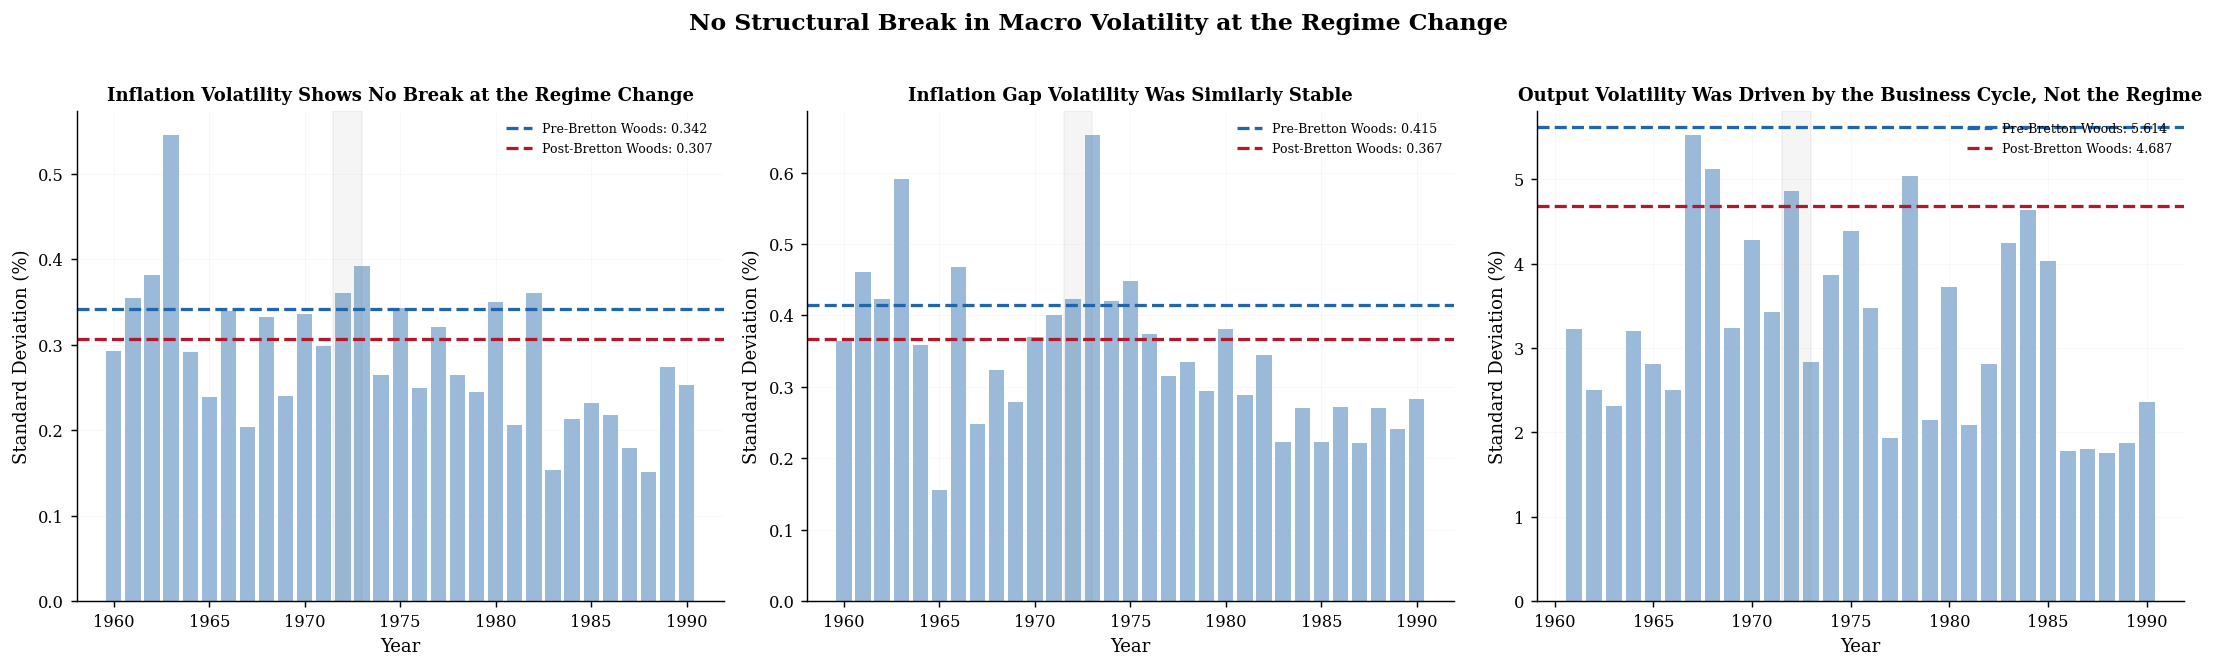

In [16]:
# ─── Yearly standard deviations over time ───
# The yearly bars show whether high/low volatility years cluster around
# the regime break or are spread throughout. if the break mattered,
# we'd see bars jump at 1971/73. The horizontal reference lines make it such that
# each year's volatility is comparable.
# Coursework: "you should have 31 data points showing the standard deviation
# of inflation in each year from 1960 - 1990."
# For 12-month IP growth, 1960 has only 1 valid observation (Dec 1960 is the
# first month with a 12-month-ago comparison), so its yearly SD is undefined.
# This gives 30 data points (1961–1990) for that variable.
yearly_vars = {
    'Inflation, Germany (%)'  : 'inf_de',
    'Inflation Diff DE−US (%)' : 'inf_diff',
    '12-Month IP Growth (%)'   : 'g_ip_12m',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('No Structural Break in Macro Volatility at the Regime Change',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (label, col) in zip(axes, yearly_vars.items()):
    # Compute SD within each calendar year
    yearly_sd = plot_df.groupby(plot_df['date'].dt.year)[col].std()

    # Bar chart of yearly SDs
    ax.bar(yearly_sd.index, yearly_sd.values, color=C_DE, alpha=0.45, edgecolor='none')

    # Overlay the overall pre-BW and post-BW SDs as horizontal reference lines
    sd_pre  = pre_bw[col].std()
    sd_post = post_bw[col].std()
    ax.axhline(sd_pre,  color=C_PRE,  linewidth=1.8, linestyle='--',
               label=f'Pre-Bretton Woods: {sd_pre:.3f}')
    ax.axhline(sd_post, color=C_POST, linewidth=1.8, linestyle='--',
               label=f'Post-Bretton Woods: {sd_post:.3f}')

    # Shade the transition period
    ax.axvspan(1971.5, 1973, alpha=0.08, color='grey')

    # Informative subplot titles. state the finding, not the variable
    yearly_titles = {
        'Inflation, Germany (%)'  : 'Inflation Volatility Shows No Break at the Regime Change',
        'Inflation Diff DE−US (%)' : 'Inflation Gap Volatility Was Similarly Stable',
        '12-Month IP Growth (%)'   : 'Output Volatility Was Driven by the Business Cycle, Not the Regime',
    }
    ax.set_title(yearly_titles.get(label, label), fontsize=10)
    ax.set_xticks(range(1960, 1991, 5))
    ax.set_xlabel('Year')
    ax.set_ylabel('Standard Deviation (%)')
    ax.legend(fontsize=7, frameon=False)

plt.tight_layout()
plt.show()

The yearly SD bars confirm the table's finding that there is no visible
structural break in macro volatility around 1971-73. The highest
volatility years for IP growth (1974-75) correspond to the oil crisis,
not the regime change. The pre- and post-BW reference lines sit at
nearly the same height for all three variables.

### 4.3 Question

**Why exclude July 1971 – February 1973?**

This is the transition period between the fixed and floating regimes,
during which exchange rates were neither cleanly pegged nor cleanly
floating. Germany temporarily floated the DEM in May 1971, the Nixon
Shock followed in August 1971 and the **Smithsonian Agreement** of
December 1971 attempted to re-establish fixed rates with wider bands.
This arrangement itself collapsed by March 1973, at which point
currencies moved to a free float.

Including this period in either sample would contaminate the estimates.
Adding it to the pre-BW period would inflate the measured volatility
of a regime that was, in principle, fixed. Adding it to the post-BW
period would dilute the measured volatility of the floating regime.
The identification strategy relies on comparing two cleanly distinct
regimes, a sharp discontinuity in exchange rate volatility while
other factors were evolving continuously (W4, slide 20). The
transition period is precisely when this clean separation breaks down,
so excluding it keeps the comparison clean.

### 4.4 Regression Analysis

#### 6-Month Standard Deviations

In [17]:
# ─── Compute 6-month standard deviations ───
# Assign each month to a half-year period: Jan–Jun = H1, Jul–Dec = H2.
# We build string labels (e.g. '1985-H2') rather than using pd.PeriodIndex
# because the groupby output is more readable and easier to verify.
plot_df['half'] = (plot_df['date'].dt.year.astype(str) + '-H' +
                   ((plot_df['date'].dt.month > 6).astype(int) + 1).astype(str))

# Group by half-year and compute the SD of each variable within each period
six_month_sd = (plot_df
    .groupby('half')[['g_e_real', 'inf_de', 'inf_diff', 'g_ip_12m']]
    .std()
    .rename(columns={
        'g_e_real': 'sd_rer', 'inf_de': 'sd_inf_de',
        'inf_diff': 'sd_inf_diff', 'g_ip_12m': 'sd_ip12'
    })
    .reset_index())

# ── Verification ──
# Coursework requires checking one 6-month period for EACH variable.
# We manually compute SDs for 1985-H2 and compare to the grouped table.
# We pick 1985-H2 for verification: it falls well within the post-BW
# floating period (avoiding edge effects from the transition), and
# is far enough from the sample endpoints that all variables have
# complete data for the full 6-month window.
check_half = '1985-H2'
check_rows = plot_df[plot_df['half'] == check_half]
check_table = six_month_sd[six_month_sd['half'] == check_half]

print(f'Verification: {check_half} ({len(check_rows)} observations)')
print(f'{"Variable":<25} {"Manual SD":>12} {"Table SD":>12} {"Match":>8}')
print('─' * 60)
for orig, agg in [('g_e_real','sd_rer'), ('inf_de','sd_inf_de'),
                   ('inf_diff','sd_inf_diff'), ('g_ip_12m','sd_ip12')]:
    manual = check_rows[orig].std()
    table  = check_table[agg].values[0]
    ok = '✓' if abs(manual - table) < 1e-10 else '✗'
    print(f'{orig:<25} {manual:>12.6f} {table:>12.6f} {ok:>8}')

Verification: 1985-H2 (6 observations)
Variable                     Manual SD     Table SD    Match
────────────────────────────────────────────────────────────
g_e_real                      2.923529     2.923529        ✓
inf_de                        0.177498     0.177498        ✓
inf_diff                      0.139319     0.139319        ✓
g_ip_12m                      1.890867     1.890867        ✓


#### Regressions & Graphs

Dependent Variable                      β    SE(β)       R²          p
──────────────────────────────────────────────────────────────────────
SD of Inflation (Germany)         -0.0131   0.0106   0.0256     0.2222
SD of Inflation Difference         0.0090   0.0140   0.0070     0.5248
SD of 12-Month IP Growth          -0.0957   0.1348   0.0086     0.4809


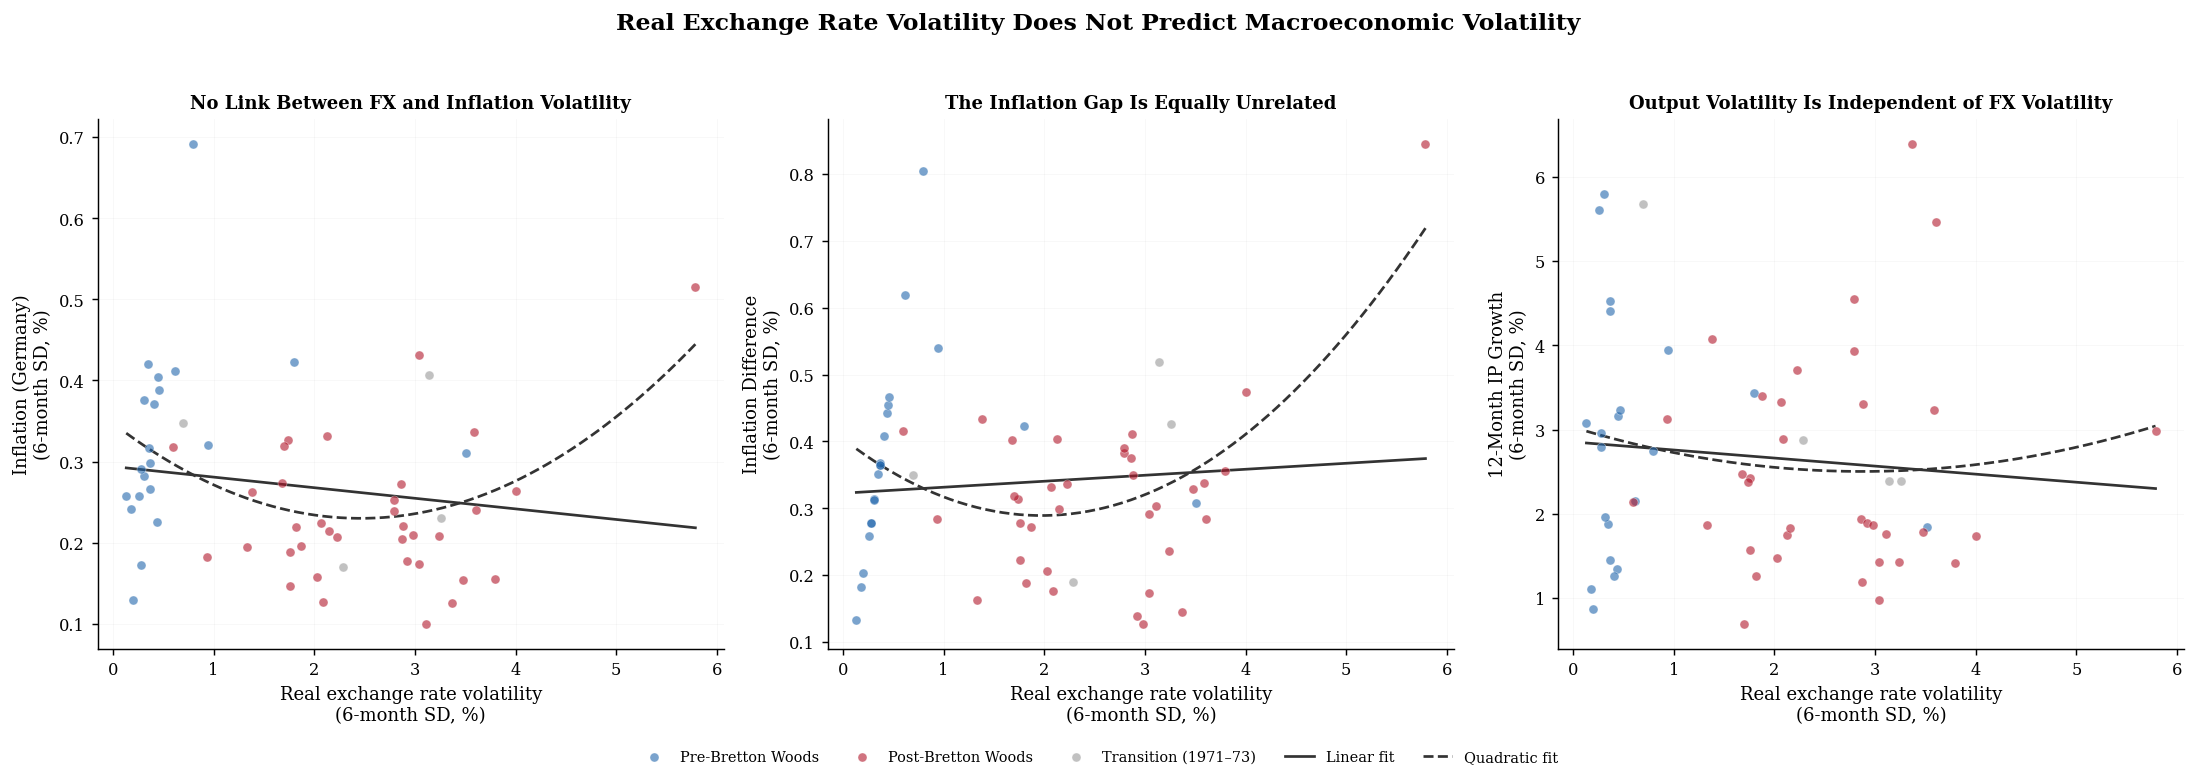

In [18]:
# ─── Classify each 6-month period by regime ───
# This lets us colour-code the scatter plot points (coursework: "use colours/
# formatting to show the key point from your graphs as clearly as possible").
half_starts = plot_df.groupby('half')['date'].min().reset_index()
half_starts.columns = ['half', 'start_date']
reg_df = six_month_sd.merge(half_starts, on='half').dropna(
    subset=['sd_rer', 'sd_inf_de', 'sd_inf_diff', 'sd_ip12'])

# Assign regime period based on the start date of each half-year
reg_df['period'] = 'Transition'
reg_df.loc[reg_df['start_date'] <= '1971-06-01', 'period'] = 'Pre-BW'
reg_df.loc[reg_df['start_date'] >= '1973-03-01', 'period'] = 'Post-BW'

# The three regressions specified by the coursework (Section 4.4):
# Y = macro volatility measure, X = real exchange rate volatility.
# We use scipy.stats.linregress rather than statsmodels because it
# returns everything we need (slope, intercept, R, p, SE) in a single
# call without additional imports. The coursework does not require
# residual diagnostics or confidence intervals.
# Note: the transition-period half-years ARE included in the regression,
# coloured grey in the scatter plots. Excluding them would remove the
# intermediate-volatility observations, but the coursework does not
# specify exclusion here (unlike Section 4.3). Including them gives
# the regression more data points in the middle of the x-axis range.
dep_vars = {
    'SD of Inflation (Germany)': 'sd_inf_de',
    'SD of Inflation Difference': 'sd_inf_diff',
    'SD of 12-Month IP Growth': 'sd_ip12',
}
period_labels = {'Pre-BW': 'Pre-Bretton Woods', 'Post-BW': 'Post-Bretton Woods', 'Transition': 'Transition (1971–73)'}
period_colours = {'Pre-BW': C_PRE, 'Post-BW': C_POST, 'Transition': C_TRANS}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle('Real Exchange Rate Volatility Does Not Predict Macroeconomic Volatility',
             fontsize=13, fontweight='bold', y=1.03)

# Print regression results as a table alongside the scatter plots.
# The table gives precise statistical evidence (β, p-values, R²),
# while the scatter plots show the economic pattern visually.
# both are needed because the Mussa puzzle is about the *absence*
# of a relationship, which requires both statistical and visual support.
print(f'{"Dependent Variable":<32} {"β":>8} {"SE(β)":>8} {"R²":>8} {"p":>10}')
print('─' * 70)

for ax, (label, col) in zip(axes, dep_vars.items()):
    x = reg_df['sd_rer'].values
    y = reg_df[col].values

    # Scatter plot with points coloured by regime period
    for period, colour in period_colours.items():
        mask = reg_df['period'] == period
        ax.scatter(x[mask], y[mask], c=colour, s=25, alpha=0.6,
                   label=period_labels[period], edgecolors='white', linewidth=0.3, zorder=3)

    # Linear fit: Y = α + βX
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, intercept + slope * x_line, color='#333333',
            linewidth=1.5, label='Linear fit', zorder=2)

    # Quadratic fit: Y = α + β₁X + β₂X²
    # Including both fits shows whether a non-linear
    # relationship is hidden by the linear specification. if the
    # quadratic diverges meaningfully from the linear, the linear
    # model would be misleading. Here, both are essentially flat.
    coeffs = np.polyfit(x, y, 2)
    ax.plot(x_line, np.polyval(coeffs, x_line), color='#333333',
            linewidth=1.5, linestyle='--', label='Quadratic fit', zorder=2)

    # Informative subplot titles
    reg_titles = {
        'SD of Inflation (Germany)': 'No Link Between FX and Inflation Volatility',
        'SD of Inflation Difference': 'The Inflation Gap Is Equally Unrelated',
        'SD of 12-Month IP Growth': 'Output Volatility Is Independent of FX Volatility',
    }
    ax.set_title(reg_titles.get(label, label), fontsize=10)
    ax.set_xlabel('Real exchange rate volatility\n(6-month SD, %)')
    ax.set_ylabel(f'{label.replace("SD of ", "")}\n(6-month SD, %)')

    # Print regression results for this dependent variable
    print(f'{label:<32} {slope:>8.4f} {se:>8.4f} {r**2:>8.4f} {p:>10.4f}')

# Single shared legend below all three subplots
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=5, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()

### 4.4 Questions

**Comment on the results.**

All three regressions produce statistically insignificant slopes (p-values of 0.22, 0.52, and 0.48) and negligible R² values (all below 3%). FX
volatility changed dramatically across regimes while macro volatility
did not. Both the linear and quadratic slopes are also economically tiny. For inflation, a 1 percentage point increase in 6-month real exchange rate volatility is associated with just a 0.013pp *decrease* in inflation volatility, an effect indistinguishable from zero. There is no meaningful relationship between exchange rate volatility and macroeconomic volatility.

The scatter plots confirm this visually. Pre-BW points cluster at low FX volatility and post-BW points spread across high FX volatility, yet both sit at similar heights on the y-axis. The colour coding makes the Mussa puzzle visible at a glance.

This replicates the central finding of Itskhoki & Mukhin (2021) for Germany. In their US data, FX volatility increased roughly 5× at the end of Bretton Woods with no corresponding change in macro volatility. Our German data shows a smaller increase of approximately 3×, consistent with Germany having already experienced some exchange rate adjustment within Bretton Woods (the 1961 and 1969 revaluations). The jump to floating was therefore less extreme than for the US.

**What regressions have been implicitly run to produce the different
lines of best fit?**

The **linear fit** estimates $Y = \alpha + \beta X$ by OLS, a
constant marginal relationship between exchange rate volatility and
macro volatility.

The **quadratic fit** estimates $Y = \alpha + \beta_1 X + \beta_2 X^2$
by OLS, a polynomial regression of degree 2, which allows the
relationship to be non-linear. In the inflation difference panel,
the quadratic curve bends upward at high FX volatility, but this
is driven by a small number of outlier observations rather than
a systematic pattern. The linear and quadratic fits are both
essentially flat across the bulk of the data.

## 5. Extensions

### 5.1 Studying Levels vs Volatility

In Section 4, we showed that exchange rate **volatility** changed sharply at the
end of Bretton Woods while macroeconomic volatility did not. Here we ask whether
the average **levels** of exchange rates, inflation, and industrial production
growth also change discontinuously?

We define windows of varying size around the BW break and compare average
levels before and after. The pre-BW period always ends at June 1971 while the
post-BW period always starts at March 1973.

In [19]:
# ─── Compare average levels at different window sizes ───
# Using the same pre/post cutoffs as Section 4.3 (06/1971 and 03/1973),
# but varying how far before and after we look.
# We choose ±1, ±2, and ±5 year windows to show how sensitive the
# level comparison is to the time horizon: narrow windows isolate the
# regime change but have few observations, while wider windows gain
# statistical power but risk contamination from confounding events
# (as the 5.1 questions will discuss).
level_vars = {
    'Nom FX Growth (%)': 'g_e_nom',
    'Real FX Growth (%)': 'g_e_real',
    'Inflation DE (%)': 'inf_de',
    '12m IP Growth (%)': 'g_ip_12m',
}

windows = [
    ('±1 year',  '1970-07-01', '1971-06-01', '1973-03-01', '1974-03-01'),
    ('±2 years', '1969-07-01', '1971-06-01', '1973-03-01', '1975-03-01'),
    ('±5 years', '1966-07-01', '1971-06-01', '1973-03-01', '1978-03-01'),
    ('Full sample', '1960-01-01', '1971-06-01', '1973-03-01', '1990-12-01'),
]

# Compute mean values of each variable within each window
rows = []
for wname, ps, pe, qs, qe in windows:
    pre_w  = plot_df[(plot_df['date'] >= ps) & (plot_df['date'] <= pe)]
    post_w = plot_df[(plot_df['date'] >= qs) & (plot_df['date'] <= qe)]
    row = {'Window': wname, 'Pre obs': len(pre_w), 'Post obs': len(post_w)}
    for vname, col in level_vars.items():
        row[f'{vname} Pre']  = pre_w[col].mean()
        row[f'{vname} Post'] = post_w[col].mean()
        row[f'{vname} Δ']    = post_w[col].mean() - pre_w[col].mean()
    rows.append(row)

# Display as a formatted table
levels_table = pd.DataFrame(rows).set_index('Window')
# Transpose so windows are columns and variables are rows. this lets
# allows us to scan across rows to see how one variable's result changes
# with window size, which is the key comparison in the 5.1 questions.
display(levels_table.round(3).T)

Window,±1 year,±2 years,±5 years,Full sample
Pre obs,12.000,24.000,60.000,138.000
Post obs,13.000,25.000,61.000,214.000
Nom FX Growth (%) Pre,-0.337,-0.523,-0.209,-0.125
Nom FX Growth (%) Post,-0.939,-0.967,-0.599,-0.286
Nom FX Growth (%) Δ,-0.602,-0.444,-0.390,-0.160
Real FX Growth (%) Pre,-0.388,-0.445,-0.060,-0.114
Real FX Growth (%) Post,-0.697,-0.680,-0.368,-0.041
Real FX Growth (%) Δ,-0.309,-0.235,-0.308,0.073
Inflation DE (%) Pre,0.430,0.355,0.228,0.224
Inflation DE (%) Post,0.592,0.541,0.412,0.288


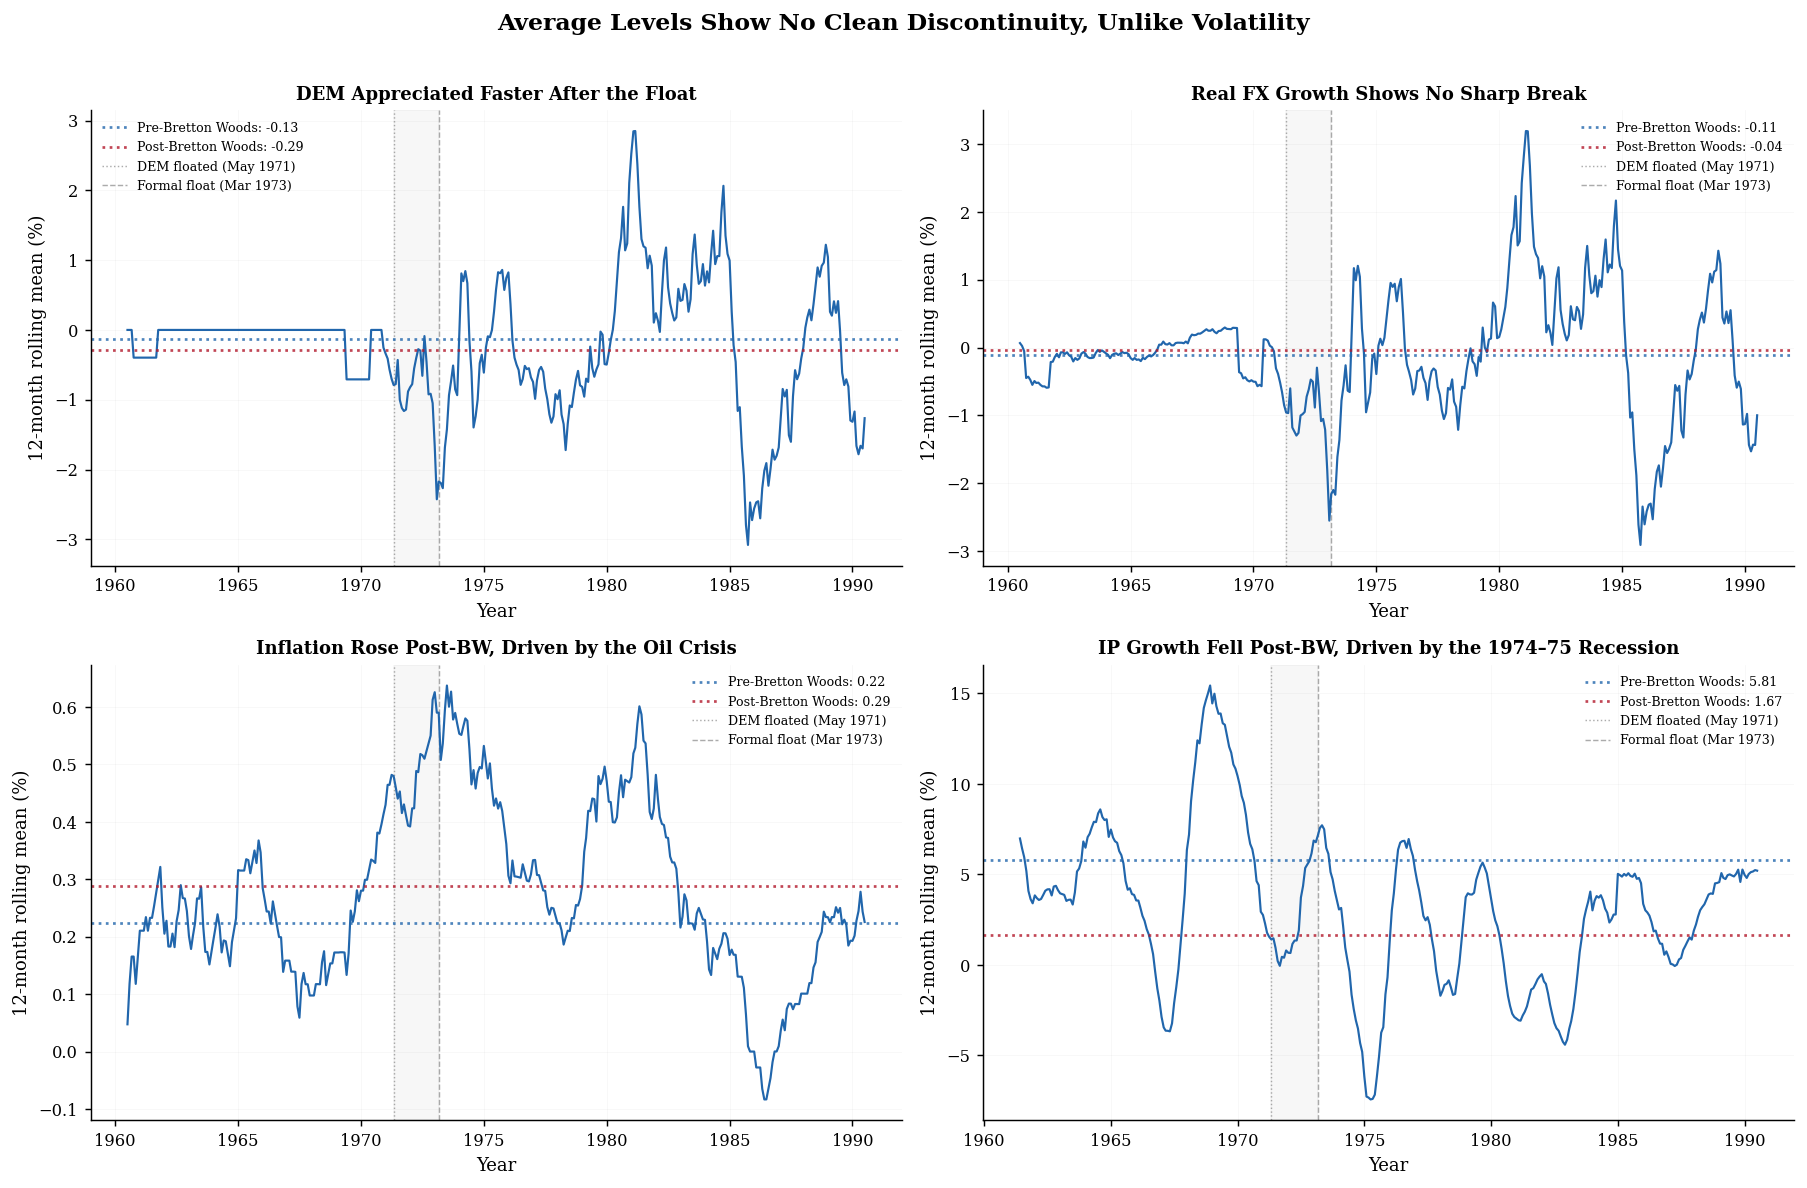

In [20]:
# ─── Rolling 12-month mean of each variable ───
# This visualises whether levels shifted discontinuously at the BW break,
# or whether any changes are gradual trends obscured by confounding events.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Average Levels Show No Clean Discontinuity, Unlike Volatility',
             fontsize=13, fontweight='bold', y=1.01)

for idx, (vname, col) in enumerate(level_vars.items()):
    ax = axes[idx // 2, idx % 2]
    # 12-month rolling mean to smooth noise
    # center=True aligns each smoothed value with the middle of its
    # 12-month window, so the plotted trend reflects the correct
    # timing rather than lagging 6 months behind.
    rolling = plot_df.set_index('date')[col].rolling(12, center=True).mean()
    ax.plot(rolling.index, rolling.values, color=C_DE, linewidth=1.2)

    # Pre and post BW means as horizontal reference lines
    pre_mean = pre_bw[col].mean()
    post_mean = post_bw[col].mean()
    ax.axhline(pre_mean, color=C_PRE, linestyle=':', linewidth=1.5, alpha=0.8,
               label=f'Pre-Bretton Woods: {pre_mean:.2f}')
    ax.axhline(post_mean, color=C_POST, linestyle=':', linewidth=1.5, alpha=0.8,
               label=f'Post-Bretton Woods: {post_mean:.2f}')

    add_bw_markers(ax)
    # Informative subplot titles. state the finding, not the variable
    informative = {
        'Nom FX Growth (%)': 'DEM Appreciated Faster After the Float',
        'Real FX Growth (%)': 'Real FX Growth Shows No Sharp Break',
        'Inflation DE (%)': 'Inflation Rose Post-BW, Driven by the Oil Crisis',
        '12m IP Growth (%)': 'IP Growth Fell Post-BW, Driven by the 1974\u201375 Recession',
    }
    ax.set_title(informative.get(vname, vname), fontsize=10)
    ax.set_ylabel('12-month rolling mean (%)')
    ax.legend(fontsize=7, frameon=False)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

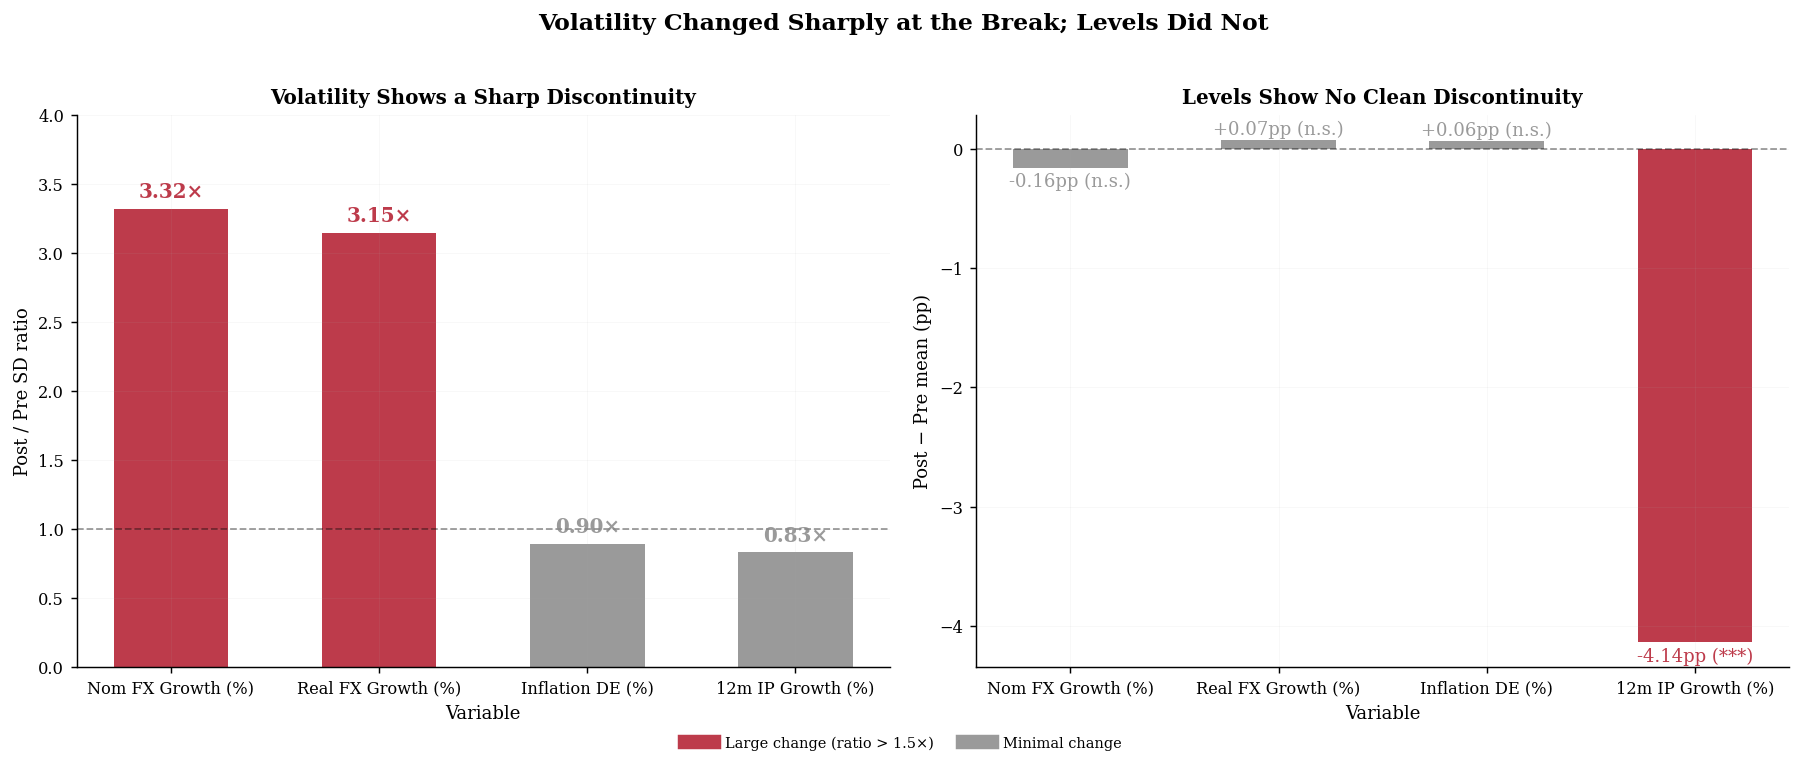


Welch t-test: post-BW mean vs pre-BW mean
Variable                    Pre mean  Post mean     Diff    p-value
─────────────────────────────────────────────────────────────────
Nom FX Growth (%)             -0.125     -0.286   -0.160     0.4459
Real FX Growth (%)            -0.114     -0.041   +0.073     0.7341
Inflation DE (%)              +0.224     +0.288   +0.064     0.0743
12m IP Growth (%)             +5.808     +1.673   -4.136     0.0000


In [21]:
# ─── Formal comparison: volatility vs level changes at BW break ───
# Juxtapose the two types of change to make Section 5.1's point explicit.
# Left: volatility ratios (post/pre SD). these are the clean discontinuity.
# Right: level differences (post mean − pre mean) with t-test p-values.
from scipy.stats import ttest_ind

compare_vars = {
    'Nom FX Growth (%)': 'g_e_nom',
    'Real FX Growth (%)': 'g_e_real',
    'Inflation DE (%)': 'inf_de',
    '12m IP Growth (%)': 'g_ip_12m',
}

fig, (ax_vol, ax_lev) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Volatility Changed Sharply at the Break; Levels Did Not',
             fontsize=13, fontweight='bold', y=1.02)

labels = list(compare_vars.keys())
x = np.arange(len(labels))
width = 0.55

# ── Left panel: volatility ratios (from Section 4.3) ──
vol_ratios = [post_bw[c].std() / pre_bw[c].std() for c in compare_vars.values()]
colors_vol = [C_POST if r > 1.5 else '#888888' for r in vol_ratios]
bars_v = ax_vol.bar(x, vol_ratios, width, color=colors_vol, alpha=0.85)
for bar, ratio in zip(bars_v, vol_ratios):
    ax_vol.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{ratio:.2f}×', ha='center', va='bottom', fontsize=11,
                fontweight='bold', color=bar.get_facecolor())
ax_vol.axhline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax_vol.set_xticks(x)
ax_vol.set_xticklabels(labels, fontsize=9)
ax_vol.set_ylabel('Post / Pre SD ratio')
ax_vol.set_title('Volatility Shows a Sharp Discontinuity', fontsize=11)
ax_vol.set_xlabel('Variable')
ax_vol.set_ylim(0, 4)

# We use a Welch t-test (equal_var=False) rather than the standard
# t-test because Section 4.3 showed the pre- and post-BW samples have very
# different variances (FX volatility tripled). A standard t-test assumes equal
# variances, which would be inappropriate here. The t-test formalises whether
# the level differences visible in the bar chart are statistically significant,
# which matters because the Section 5.1 question asks whether levels changed
# "markedly" around the end of Bretton Woods.
# ── Right panel: level differences with t-test ──
level_diffs = []
p_vals = []
for col in compare_vars.values():
    pre_vals  = pre_bw[col].dropna()
    post_vals = post_bw[col].dropna()
    level_diffs.append(post_vals.mean() - pre_vals.mean())
    _, p = ttest_ind(pre_vals, post_vals, equal_var=False)
    p_vals.append(p)

colors_lev = ['#888888' if p > 0.05 else C_POST for p in p_vals]
bars_l = ax_lev.bar(x, level_diffs, width, color=colors_lev, alpha=0.85)
for bar, diff, p in zip(bars_l, level_diffs, p_vals):
    y_pos = bar.get_height() + 0.01 if bar.get_height() >= 0 else bar.get_height() - 0.04
    va = 'bottom' if bar.get_height() >= 0 else 'top'
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else 'n.s.')
    ax_lev.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{diff:+.2f}pp ({sig})', ha='center', va=va, fontsize=10,
                color=bar.get_facecolor())
ax_lev.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax_lev.set_xticks(x)
ax_lev.set_xticklabels(labels, fontsize=9)
ax_lev.set_ylabel('Post − Pre mean (pp)')
ax_lev.set_title('Levels Show No Clean Discontinuity', fontsize=11)
ax_lev.set_xlabel('Variable')

# Colour legend: red = large change, grey = minimal change
vol_legend = [
    Line2D([0], [0], color=C_POST, linewidth=8, alpha=0.85, label='Large change (ratio > 1.5×)'),
    Line2D([0], [0], color='#888888', linewidth=8, alpha=0.85, label='Minimal change'),
]
fig.legend(handles=vol_legend, loc='lower center', ncol=2, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.show()

# Print the t-test results for the written answer
print('\nWelch t-test: post-BW mean vs pre-BW mean')
print(f'{"Variable":<25} {"Pre mean":>10} {"Post mean":>10} {"Diff":>8} {"p-value":>10}')
print('─' * 65)
for label, col in compare_vars.items():
    pre_m  = pre_bw[col].mean()
    post_m = post_bw[col].mean()
    _, p   = ttest_ind(pre_bw[col].dropna(), post_bw[col].dropna(), equal_var=False)
    print(f'{label:<25} {pre_m:>+10.3f} {post_m:>+10.3f} {post_m - pre_m:>+8.3f} {p:>10.4f}')

The side-by-side comparison makes the Section 5.1 argument concrete. The left panel shows a clean volatility discontinuity. Both nominal and real FX volatility tripled (3.32× and 3.15×) while inflation and IP volatility barely moved (0.90× and 0.83×). The right panel asks whether average levels showed a similarly clean break.

They did not. Nominal FX growth fell by 0.16pp (the DEM appreciated slightly faster after the float), but this is statistically insignificant. Real FX growth barely changed (+0.07pp, n.s.) because the inflation differential between Germany and the US partially offset the nominal appreciation. Inflation rose marginally (+0.06pp, n.s.), consistent with the gradual inflationary trend visible in the rolling mean graphs rather than a discrete regime effect.
The only statistically significant level change is 12-month IP growth, which fell by 4.14pp (p < 0.01). But this is driven by the 1974–75 oil crisis recession, not the exchange rate regime change.

The rolling mean graph in the previous cell shows IP growth was already plunging before the formal float in March 1973. The Welch t-test picks up a genuine difference in means, but the cause is a global supply shock, not the end of Bretton Woods.

This is discussed in Section 5.1. Volatility provides a clean discontinuity that can be attributed to the regime change. Level comparisons are contaminated by confounding events, which is why Itskhoki & Mukhin (2021) focus on volatility as the stronger identification strategy.

We use Welch t-tests which, unlike the standard t-test, do not assume both samples have the same variance, an important distinction given that Section 4.3 showed FX volatility tripled. The tests confirm that while the level differences exist on paper, they cannot be cleanly attributed to the BW break, unlike the volatility discontinuity, which is both statistically and economically sharp.

### 5.1 Questions

**Is there evidence that average levels changed markedly around the end of
Bretton Woods?**

The multi-window table above shows that nominal and real exchange rate
growth rates did shift. The DEM appreciated faster against the dollar
after the float (mean monthly nominal FX growth went from −0.13% to
−0.29% over the full sample). However, the rolling mean graph shows
that this was a gradual trend rather than a sharp discontinuity at
the BW break. Exchange rate levels drifted steadily. There
is no clean "jump" comparable to the dramatic volatility break documented
in Section 4.

Inflation in Germany was slightly higher on average post-BW (0.29% vs 0.22%
monthly), but this is driven by the 1973 oil crisis and global inflationary
pressures, not the exchange rate regime change itself.

For industrial production growth, the table reveals a striking
sensitivity to window size. A narrow ±1 year window shows IP growth
was *higher* after BW (+2.1pp), while a ±2 or ±5 year window shows
it was dramatically *lower* (−5.0 to −5.8pp) because the 1974–75
recession falls into the post-BW window. Unlike volatility, the level
comparison is sensitive to confounding events.

**How do your results change as you consider longer periods?**

Longer periods amplify the influence of confounding events. The 1973 oil
crisis, the 1974–75 recession, the 1979 oil shock, and the Volcker
disinflation all affect the post-BW averages. The ±1 year window gives
the cleanest comparison but has very few observations. As the window
expands, we gain statistical power but lose causal identification.
The estimated "effect" of the exchange rate regime change becomes
increasingly contaminated by unrelated macroeconomic shocks.

**What issues are there with longer-period analysis for causal inference?**

The identification strategy in Section 4 works because exchange rate
volatility changed *discontinuously* at the BW break (a regression
discontinuity design, W4 slide 20). Other factors (inflation, fiscal
policy, global capital flows) were evolving *continuously*, so they
are held approximately constant across the discontinuity.

Level analysis undermines this logic. Levels change gradually, so the
"treatment" (exchange rate level change) is not cleanly separated from
confounding factors (oil prices, monetary policy shifts, the global
business cycle). Any pre-post difference in levels could be driven by
the regime change *or* by these confounds. The IP growth example makes
this concrete. The ±2yr result is dominated by the 1974–75 recession,
which was caused by the oil crisis, not by the end of Bretton Woods.

The volatility-based approach used in Section 4
(following Itskhoki & Mukhin, 2021) is more powerful. Exchange rate
volatility changed *discontinuously* at the regime break, so the
confounding factors that contaminate level comparisons are held
approximately constant across the discontinuity. Level analysis
has no such advantage.

The juxtaposition figure above makes this contrast visually explicit.
The volatility panel shows a clean 3× discontinuity in exchange rates
with no corresponding macro change, while the levels panel shows
differences that are either insignificant or confounded. This is why
the volatility-based approach is the stronger identification strategy.

### 5.2 Black Wednesday: The UK Joining & Leaving the ERM

The UK joined the ERM on 08/10/1990, pegging the pound to the DM at
£1 = DM 2.95 (±6% band: 2.773–3.127). The UK was forced out on
16/09/1992 ("Black Wednesday") after a speculative attack.

We import additional UK and Germany data from the IMF IFS and construct
the DM/£ cross-rate from the dollar rates:
DM per £ = (DEM/USD) / (GBP/USD).

We apply the same analytical framework from Section 4 to the ERM period,
first examining volatility changes across regime periods, then level changes.
The key difference is that the ERM period is much shorter (24 months under
the peg), which limits the statistical power of the comparison.

In [22]:
# ─── Load UK and extended Germany data for the ERM period (1985–1995) ───
# 1985–1995 gives roughly 5 years either side of the ERM period
# (Oct 1990 – Sep 1992), providing enough pre- and post-regime data
# for meaningful volatility and level comparisons.
ERM_START = '1985-01-01'
ERM_END   = '1995-12-01'

# We define a separate load_imf_erm() rather than parameterising load_imf()
# because the two functions serve different sections and changing load_imf()
# would risk breaking the Section 2-4 pipeline. Keeping them separate means
# each section's data loading is self-contained and independently verifiable.
def load_imf_erm(path, value_col_name):
    """Load IMF data filtered to the ERM study period (1985–1995).
    Same cleaning logic as load_imf() in Section 2, but for a different date range."""
    raw = pd.read_csv(path)
    monthly = raw[raw['FREQUENCY'] == 'Monthly'].copy()
    monthly['date'] = pd.to_datetime(
        monthly['TIME_PERIOD'].str.replace('-M', '-', regex=False), format='%Y-%m')
    monthly[value_col_name] = pd.to_numeric(monthly['OBS_VALUE'], errors='coerce')
    study = (monthly[['date', value_col_name]]
             .loc[(monthly['date'] >= ERM_START) & (monthly['date'] <= ERM_END)]
             .sort_values('date').reset_index(drop=True))
    fname = path.split('/')[-1]
    print(f"  {fname:25s} │ {len(study):3d} rows │ {study['date'].min():%Y-%m} to {study['date'].max():%Y-%m}")
    return study


print("── Loading ERM-period data ──\n")
# UK series
er_uk  = load_imf_erm(FOLDER + 'ER_UK.csv',      'e_uk')     # GBP per USD
cpi_uk = load_imf_erm(FOLDER + 'CPI_UK.csv',     'cpi_uk')   # CPI index, UK
ip_uk  = load_imf_erm(FOLDER + 'PI_UK.csv',      'ip_uk')    # IP index, UK
res_uk = load_imf_erm(FOLDER + 'IL_UK.csv',      'res_uk')   # Reserves, USD millions

# Germany series (extended to 1995)
er_de_erm  = load_imf_erm(FOLDER + 'ER_Germany.csv',  'e_de')
cpi_de_erm = load_imf_erm(FOLDER + 'CPI_Germany.csv', 'cpi_de_erm')

# Merge into a single ERM DataFrame
erm = (er_uk.merge(er_de_erm, on='date')
       .merge(cpi_uk, on='date')
       .merge(cpi_de_erm, on='date')
       .merge(ip_uk, on='date')
       .merge(res_uk, on='date'))

print(f"\nMerged: {len(erm)} rows, {erm['date'].min():%Y-%m} to {erm['date'].max():%Y-%m}")
print(f"Missing: {erm.isnull().sum().sum()}")

── Loading ERM-period data ──

  ER_UK.csv                 │ 132 rows │ 1985-01 to 1995-12
  CPI_UK.csv                │ 132 rows │ 1985-01 to 1995-12
  PI_UK.csv                 │ 132 rows │ 1985-01 to 1995-12
  IL_UK.csv                 │ 132 rows │ 1985-01 to 1995-12
  ER_Germany.csv            │ 132 rows │ 1985-01 to 1995-12
  CPI_Germany.csv           │ 132 rows │ 1985-01 to 1995-12

Merged: 132 rows, 1985-01 to 1995-12
Missing: 0


In [23]:
# ─── Construct ERM variables ───

# DM/£ cross-rate: (DEM/USD) / (GBP/USD)
# The IMF IFS doesn't provide DM/£ directly. only each currency
# against the USD. We infer the bilateral rate from the two dollar rates.
# e.g. DEM/USD=1.8, GBP/USD=0.6 → DM/£ = 1.8/0.6 = 3.0
erm['dm_per_gbp'] = erm['e_de'] / erm['e_uk']

# Real exchange rate DM/£ = (DM/£) × P_UK / P_DE
# This follows the same logic as Section 4's RER (E × P_foreign / P_home),
# but now measures the bilateral UK-Germany rate rather than US-Germany.
# A higher value means UK goods are more expensive in German terms.
erm['rer'] = erm['dm_per_gbp'] * (erm['cpi_uk'] / erm['cpi_de_erm'])
erm['g_rer'] = erm['rer'].pct_change() * 100

# UK and German inflation (%)
erm['inf_uk'] = erm['cpi_uk'].pct_change() * 100
erm['inf_de_erm'] = erm['cpi_de_erm'].pct_change() * 100

# UK industrial production growth (12-month only).
# We use 12-month growth for volatility/level analysis, consistent with
# Section 4. as discussed in 4.2, it removes seasonal noise that would
# obscure the comparison across regime periods.
erm['g_ip_uk_12m'] = erm['ip_uk'].pct_change(periods=12) * 100

# UK reserves index (Jan 1985 = 100)
res_uk_base = erm.loc[erm['date'] == '1985-01-01', 'res_uk'].values[0]
erm['res_uk_idx'] = (erm['res_uk'] / res_uk_base) * 100

# Key dates
ERM_JOIN  = pd.Timestamp('1990-10-01')   # UK joins ERM
BLACK_WED = pd.Timestamp('1992-09-01')   # Black Wednesday month

# ─── Define sub-periods ───
# Pre-ERM uses all available data (Jan 1985 – Sep 1990), consistent with
# Section 4 where we used the full pre-BW sample rather than a symmetric window.
pre_erm    = erm[(erm['date'] >= '1985-01-01') & (erm['date'] < ERM_JOIN)]
during_erm = erm[(erm['date'] >= ERM_JOIN) & (erm['date'] <= BLACK_WED)]
post_erm   = erm[(erm['date'] > BLACK_WED) & (erm['date'] <= '1995-12-01')]

print('ERM variables constructed.')
print(f'Pre-ERM (Jan 1985 – Sep 1990): {len(pre_erm)} obs')
print(f'During ERM (Oct 1990 – Sep 1992): {len(during_erm)} obs')
print(f'Post-ERM (Oct 1992 – Dec 1995): {len(post_erm)} obs')

ERM variables constructed.
Pre-ERM (Jan 1985 – Sep 1990): 69 obs
During ERM (Oct 1990 – Sep 1992): 24 obs
Post-ERM (Oct 1992 – Dec 1995): 39 obs


A note on boundaries. We assign September 1992 to 'during ERM' even
though Black Wednesday fell mid-month (16 Sep). The IMF monthly data
averages across the whole month, so the September value blends pre-
and post-attack observations. Assigning it to the pegged period is
conservative, understating post-exit volatility rather than
overstating it.

In [24]:
# ─── Verify the cross-rate against known ERM values ───
# Since the cross-rate is derived (not downloaded), we verify it
# against the known ERM peg (2.95) and band (2.773–3.127) to
# confirm the division is correct and not inverted.
# Sep 1992 is an average over the whole month. includes days before AND
# after Black Wed (16 Sep), so it falls below the band.
print('=== DM/£ Cross-Rate at Key Dates ===')
for d, note in [('1990-09-01','month before ERM entry'),
                ('1990-10-01','UK joins ERM (peg = 2.95)'),
                ('1992-08-01','month before Black Wed'),
                ('1992-09-01','Black Wednesday month'),
                ('1992-10-01','first full month after')]:
    row = erm[erm['date']==d]
    if len(row)>0:
        dm = row['dm_per_gbp'].values[0]
        in_band = '✓ in band' if 2.773 <= dm <= 3.127 else '✗ outside band'
        print(f'  {d}: DM/£ = {dm:.4f}  ({note}) [{in_band}]')

=== DM/£ Cross-Rate at Key Dates ===
  1990-09-01: DM/£ = 2.9503  (month before ERM entry) [✓ in band]
  1990-10-01: DM/£ = 2.9623  (UK joins ERM (peg = 2.95)) [✓ in band]
  1992-08-01: DM/£ = 2.8130  (month before Black Wed) [✓ in band]
  1992-09-01: DM/£ = 2.6773  (Black Wednesday month) [✗ outside band]
  1992-10-01: DM/£ = 2.4548  (first full month after) [✗ outside band]


The verification confirms three things. (1) the formula produces values
near the known 2.95 peg at ERM entry, so it is not inverted; (2) the
rate stayed within the ±6% band during the ERM period; (3) September
1992 falls outside the band, consistent with the mid-month crash
pulling the monthly average below the 2.773 floor.

#### 5.2.1 Why Did the UK Join the ERM?

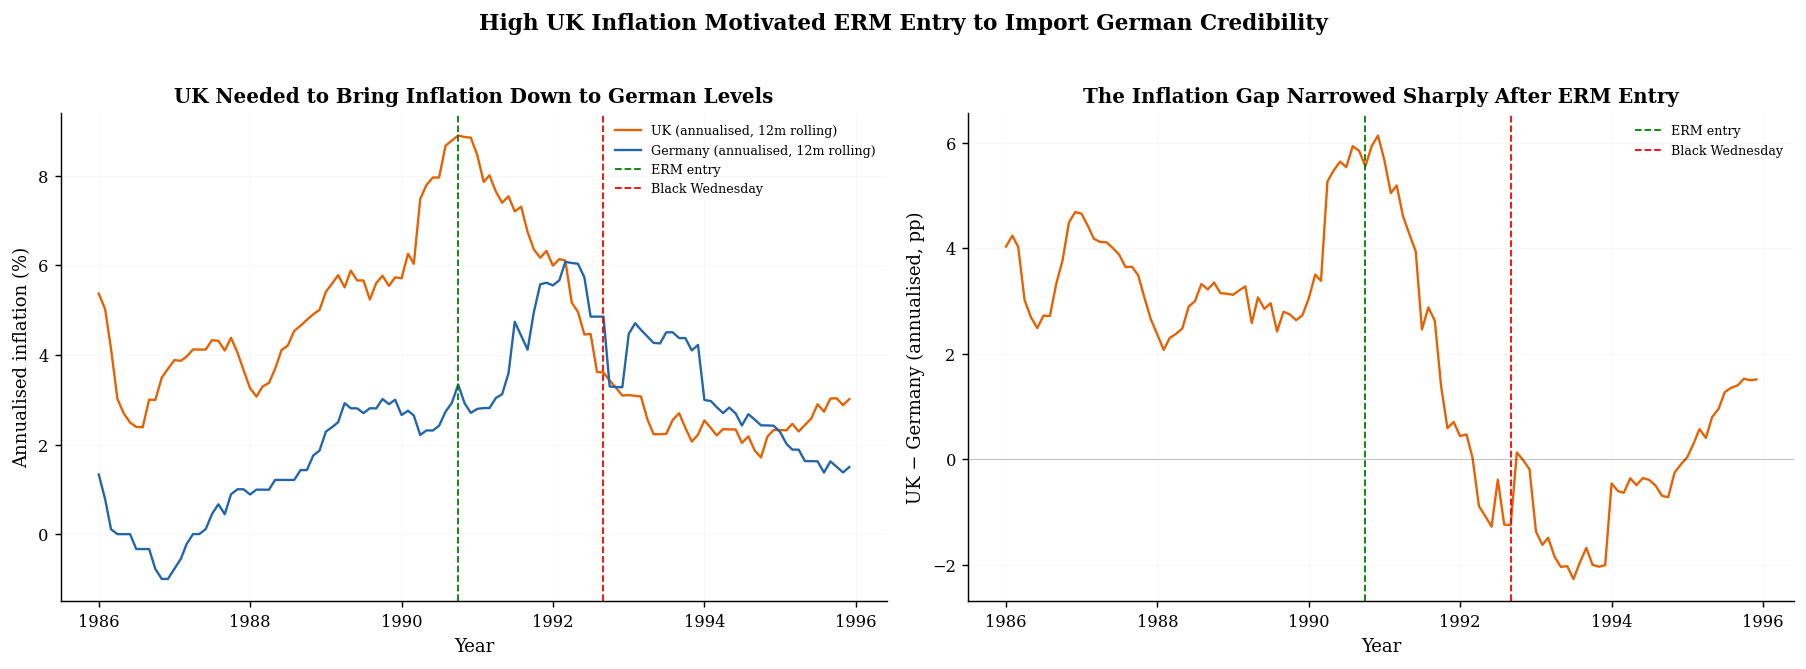

In [25]:
# ─── UK vs Germany inflation before ERM entry ───
# The UK had persistently higher inflation, motivating the peg to import
# the Bundesbank's anti-inflationary credibility.
# Two complementary views: the left panel shows the absolute levels of
# UK and German inflation (answering 'how high was each?'), while the
# right panel shows the gap directly (answering 'how far apart were they?').
# Both are needed because the gap narrowing is partly driven by German
# inflation rising (reunification), not just UK inflation falling.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('High UK Inflation Motivated ERM Entry to Import German Credibility',
             fontsize=12, fontweight='bold', y=1.02)

# Left: inflation comparison (12-month rolling mean, annualised).
# We annualise by multiplying the rolling monthly mean by 12. This
# is a standard approximation that works well when monthly rates are
# small (all below ~1% here), avoiding the complexity of compounding.
ax = axes[0]
ax.plot(erm['date'], erm['inf_uk'].rolling(12).mean() * 12, color='#e66101',
        linewidth=1.3, label='UK (annualised, 12m rolling)')
ax.plot(erm['date'], erm['inf_de_erm'].rolling(12).mean() * 12, color=C_DE,
        linewidth=1.3, label='Germany (annualised, 12m rolling)')
ax.axvline(ERM_JOIN, color='green', linestyle='--', linewidth=1, label='ERM entry')
ax.axvline(BLACK_WED, color='red', linestyle='--', linewidth=1, label='Black Wednesday')
ax.set_title('UK Needed to Bring Inflation Down to German Levels')
ax.set_ylabel('Annualised inflation (%)')
ax.legend(fontsize=7, frameon=False, loc='upper right')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year')

# Right: inflation gap (UK minus Germany)
ax = axes[1]
inf_gap = (erm['inf_uk'] - erm['inf_de_erm']).rolling(12).mean() * 12
ax.plot(erm['date'], inf_gap, color='#e66101', linewidth=1.3)
ax.axhline(0, color='black', linewidth=0.4, alpha=0.3)
ax.axvline(ERM_JOIN, color='green', linestyle='--', linewidth=1, label='ERM entry')
ax.axvline(BLACK_WED, color='red', linestyle='--', linewidth=1, label='Black Wednesday')
ax.legend(fontsize=7, frameon=False, loc='upper right')
ax.set_title('The Inflation Gap Narrowed Sharply After ERM Entry')
ax.set_ylabel('UK − Germany (annualised, pp)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

The left panel shows UK inflation consistently above Germany's before
ERM entry, with the gap widening in the late 1980s. After entry, the
two lines converge, though this partly reflects German inflation
*rising* (reunification) rather than only UK inflation falling. The
right panel isolates this. The gap narrows from about 6pp to near zero.

**What was a key reason for why the UK chose to join the ERM and fix
their exchange rate?**

The UK suffered from persistently higher inflation than Germany throughout
the late 1980s. The inflation gap graph shows UK annualised inflation
running up to 6 percentage points above Germany's, averaging around
3.5pp over 1985–1990. By pegging the pound to the Deutsche Mark, the UK
aimed to "import" the Bundesbank's anti-inflationary credibility. Under
a fixed exchange rate, the UK could not independently set interest rates.
Defending the peg effectively delegated monetary policy to the
Bundesbank, providing a nominal anchor for UK inflation expectations
(the same logic discussed in Lecture 4 for fixed exchange rate regimes,
W4 slides 48 and 53).

The inflation gap graph shows this convergence was partially underway
before ERM entry. UK inflation was already falling and German inflation
was rising due to reunification. Nonetheless, the ERM period coincided
with a further sharp narrowing of the gap, consistent with the peg
reinforcing the disinflationary trend.

#### 5.2.2 What Led to the Speculative Attack?

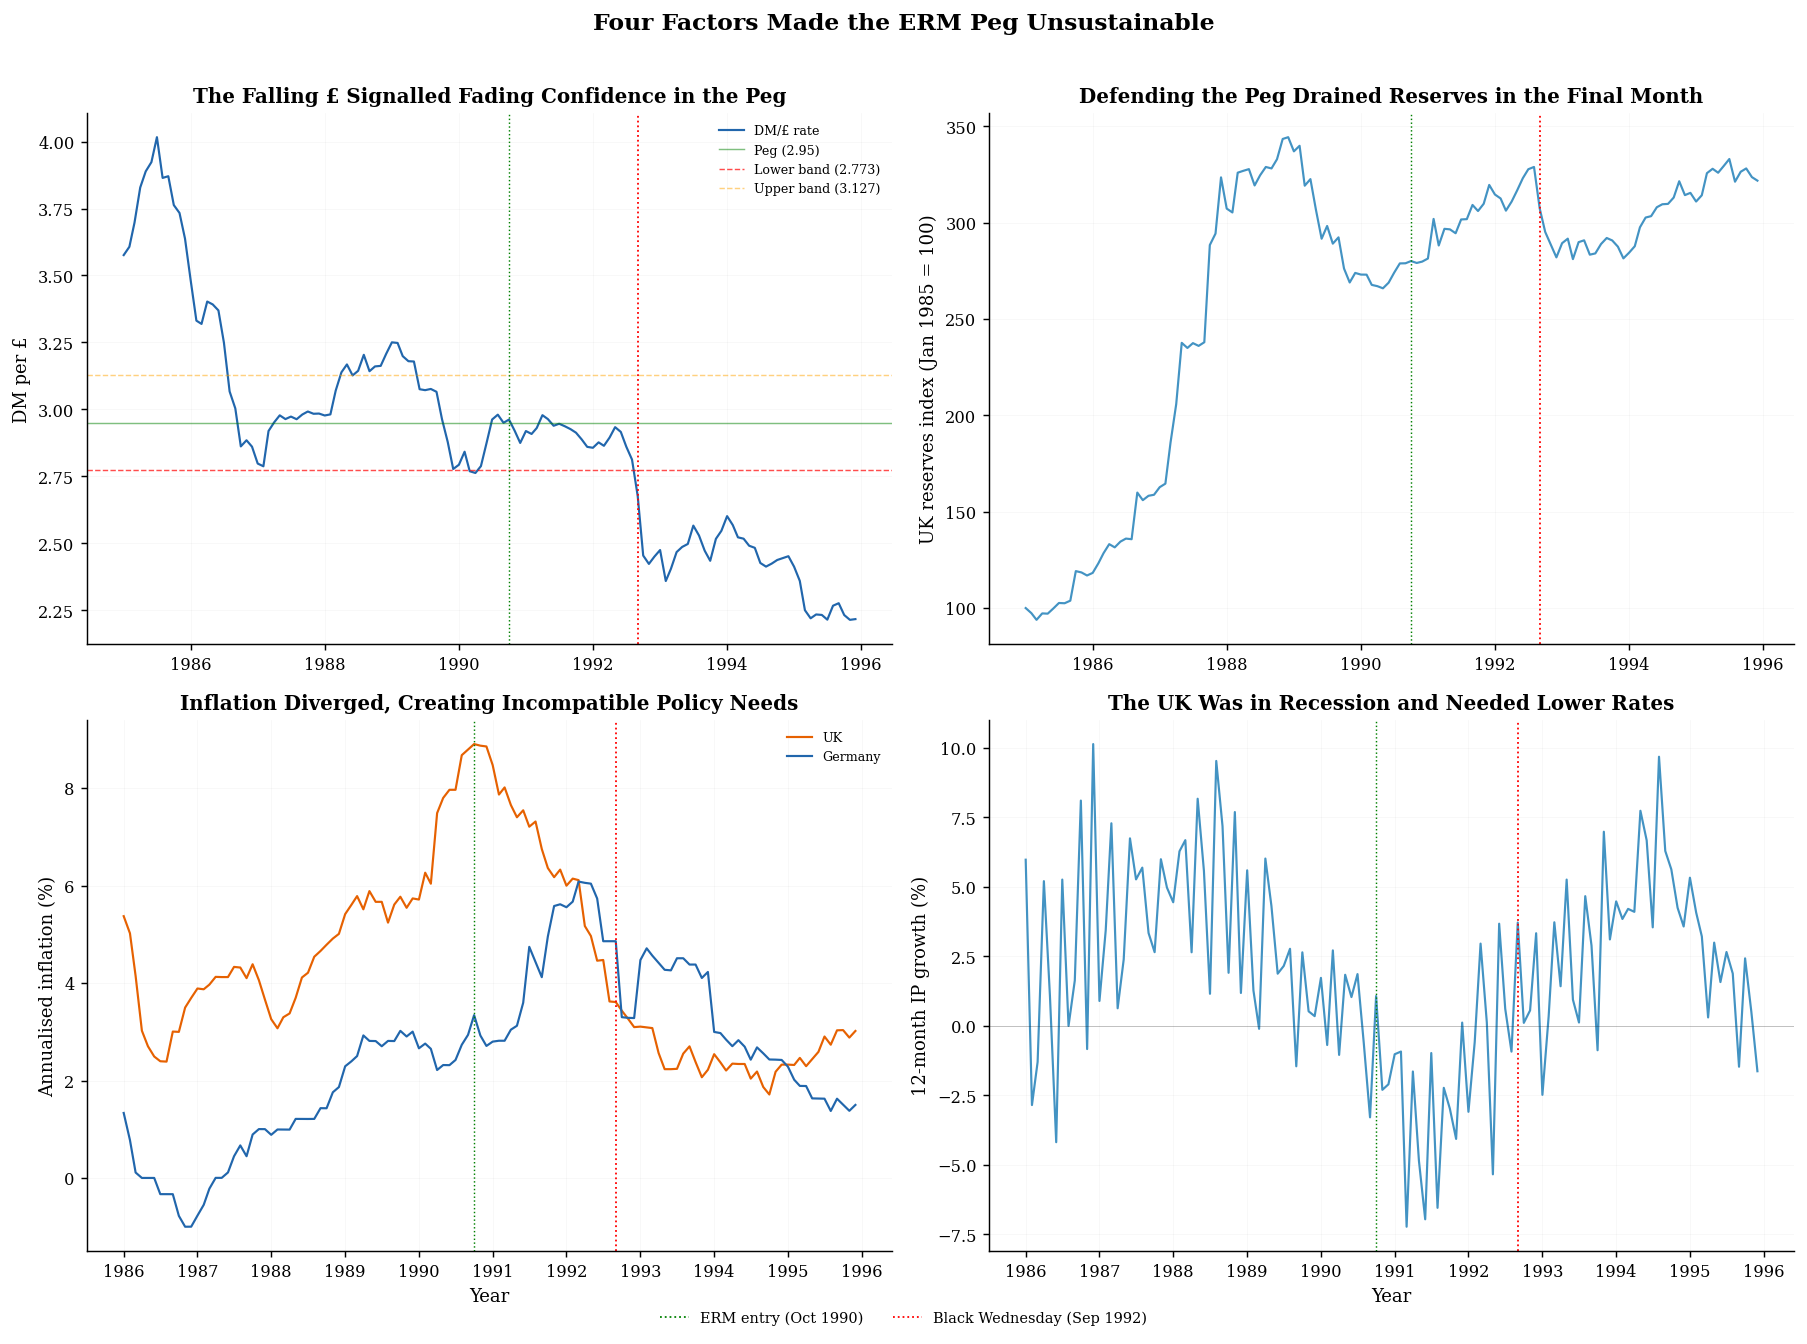

In [26]:
# ─── Four-panel figure: factors behind Black Wednesday ───
# Each panel shows one factor that made the peg unsustainable:
# (a) £ drifting to band floor. declining credibility (W4, slide 51)
# (b) Reserves under pressure. cost of defending the peg
# (c) Inflation divergence. reunification destroyed the rationale for the peg
# (d) UK in recession. the domestic cost of high interest rates
# Together they show the impossible tension the UK faced.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Four Factors Made the ERM Peg Unsustainable',
             fontsize=13, fontweight='bold', y=1.01)

# (a) DM/£ with ERM band
ax = axes[0, 0]
ax.plot(erm['date'], erm['dm_per_gbp'], color=C_DE, linewidth=1.2, label='DM/£ rate')
ax.axhline(2.95, color='green', linestyle='-', linewidth=0.8, alpha=0.5, label='Peg (2.95)')
ax.axhline(2.773, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='Lower band (2.773)')
ax.axhline(3.127, color='orange', linestyle='--', linewidth=0.8, alpha=0.5, label='Upper band (3.127)')
ax.axvline(ERM_JOIN, color='green', linestyle=':', linewidth=0.8)
ax.axvline(BLACK_WED, color='red', linestyle=':', linewidth=1)
ax.set_title('The Falling £ Signalled Fading Confidence in the Peg')
ax.set_ylabel('DM per £')
ax.legend(fontsize=7, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# (b) UK reserves
ax = axes[0, 1]
ax.plot(erm['date'], erm['res_uk_idx'], color='#4393c3', linewidth=1.2)
ax.axvline(ERM_JOIN, color='green', linestyle=':', linewidth=0.8)
ax.axvline(BLACK_WED, color='red', linestyle=':', linewidth=1)
ax.set_title('Defending the Peg Drained Reserves in the Final Month')
ax.set_ylabel('UK reserves index (Jan 1985 = 100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# (c) UK vs German inflation
ax = axes[1, 0]
ax.plot(erm['date'], erm['inf_uk'].rolling(12).mean() * 12, color='#e66101',
        linewidth=1.2, label='UK')
ax.plot(erm['date'], erm['inf_de_erm'].rolling(12).mean() * 12, color=C_DE,
        linewidth=1.2, label='Germany')
ax.axvline(ERM_JOIN, color='green', linestyle=':', linewidth=0.8)
ax.axvline(BLACK_WED, color='red', linestyle=':', linewidth=1)
ax.set_title('Inflation Diverged, Creating Incompatible Policy Needs')
ax.set_ylabel('Annualised inflation (%)')
ax.legend(fontsize=7, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year')

# (d) UK 12-month IP growth
ax = axes[1, 1]
ax.plot(erm['date'], erm['g_ip_uk_12m'], color='#4393c3', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.4, alpha=0.3)
ax.axvline(ERM_JOIN, color='green', linestyle=':', linewidth=0.8)
ax.axvline(BLACK_WED, color='red', linestyle=':', linewidth=1)
ax.set_title('The UK Was in Recession and Needed Lower Rates')
ax.set_ylabel('12-month IP growth (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year')

erm_event_handles = [
    Line2D([0], [0], color='green', linewidth=1, linestyle=':', label='ERM entry (Oct 1990)'),
    Line2D([0], [0], color='red',   linewidth=1, linestyle=':', label='Black Wednesday (Sep 1992)'),
]
fig.legend(handles=erm_event_handles, loc='lower center', ncol=2, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.show()

The four panels tell a coherent story. Panel (a): the pound drifted
from near the peg to the band floor. Panel (b): reserves grew but
dropped sharply in September 1992. Panel (c): German inflation rose
while UK inflation fell, creating a policy conflict. Panel (d): the UK
was in recession throughout the ERM period, needing rate cuts it could
not make while defending the peg.

**What factors led to George Soros and other currency speculators to
run on the pound?**

Several factors made the peg unsustainable, as shown in the graphs above.

First, German reunification (October 1990, the same month the UK joined
the ERM) created large fiscal spending in Germany, pushing German inflation
upward. The Bundesbank responded by raising interest rates. The UK was
forced to match these high rates to defend the peg, even though the UK was
in a deep recession (12-month IP growth was negative through much of
1991–92). This created an impossible tension. The UK needed lower rates to
support its domestic economy but higher rates to maintain the peg.

Second, the DM/£ rate drifted steadily toward the bottom of the permitted band throughout the ERM period. The 6% band meant the rate could not fall below DM 2.773 per pound without triggering intervention. By August 1992, the rate had reached approximately 2.81, within 1.5% of that floor. This signalled declining credibility. As Lecture 4 explains
(W4, slide 51), when a peg has low credibility, speculators act to
*destabilise* the exchange rate rather than stabilise it, selling the
currency in anticipation of devaluation, which forces the central bank
to spend reserves defending it, which further undermines credibility.
This is a self-fulfilling dynamic (W4, slide 36). The attack succeeds
partly *because* speculators expect it to succeed.

Third, defending the peg required the Bank of England to spend reserves
buying pounds whenever the rate neared the band floor. Although UK
reserves grew through most of the ERM period, the reserves graph shows
a sharp drop in September 1992 as the Bank spent billions in a single
month trying to defend the peg. Soros and other
speculators recognised this dynamic and bet heavily against the pound,
knowing the UK could not indefinitely sustain the combination of
reserve losses, high interest rates, and a domestic recession.

#### 5.2.3 Volatility Changes Around ERM Entry and Exit

The ERM gives us a floating-fixed-floating sequence, unlike Section 4's
fixed-to-floating. We can therefore test *both* directions. Did the peg
reduce FX volatility (pre vs during), and did exit restore it (during
vs post)? If both hold while macro volatility stays flat, that reinforces
the Mussa puzzle.

In [27]:
# ─── Volatility (SD) comparison across ERM sub-periods ───
erm_vol_vars = {
    'Real FX Growth (DM/£)': 'g_rer',
    'UK Inflation': 'inf_uk',
    'UK 12-Month IP Growth': 'g_ip_uk_12m',
}

# Compare the standard deviation of each variable across three sub-periods.
# Unlike Section 4 (which had a clean before/after with a transition gap),
# the ERM has three distinct regimes: floating pre-ERM, pegged during, and
# floating post-ERM. This lets us test whether the peg *reduced* volatility
# (pre vs during) and whether exit *restored* it (during vs post).
print('Standard Deviations Across ERM Periods')
print(f'{"Variable":<30} {"Pre-ERM":>10} {"During ERM":>12} {"Post-ERM":>10}')
print('─' * 65)
for label, col in erm_vol_vars.items():
    sd_pre = pre_erm[col].std()
    sd_during = during_erm[col].std()
    sd_post = post_erm[col].std()
    print(f'{label:<30} {sd_pre:>10.3f} {sd_during:>12.3f} {sd_post:>10.3f}')

Standard Deviations Across ERM Periods
Variable                          Pre-ERM   During ERM   Post-ERM
─────────────────────────────────────────────────────────────────
Real FX Growth (DM/£)               2.259        1.595      2.199
UK Inflation                        0.479        0.528      0.323
UK 12-Month IP Growth               3.284        3.077      2.701


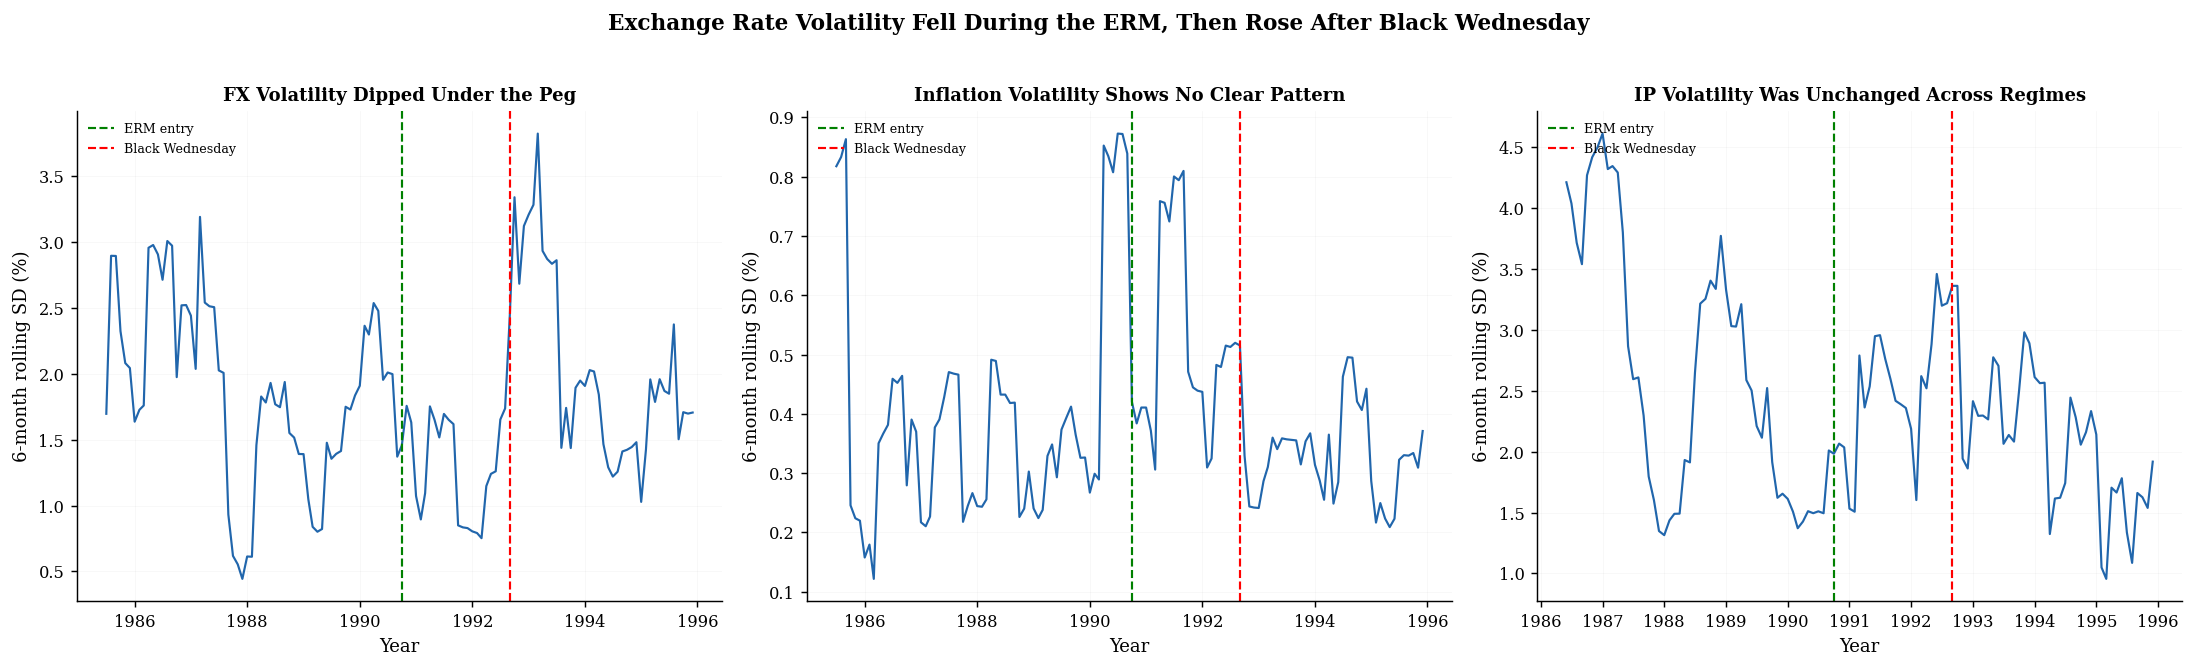

In [28]:
# ─── Rolling 6-month SD shows volatility evolution around ERM events ───
# Expect FX volatility to fall under the peg and rise after exit.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Exchange Rate Volatility Fell During the ERM, Then Rose After Black Wednesday',
             fontsize=12, fontweight='bold', y=1.02)

for ax, (label, col) in zip(axes, erm_vol_vars.items()):
    # 6-month window matches the half-year SDs used in Section 4.4,
    # giving enough observations per window while still capturing
    # short-term regime-change effects.
    rolling_sd = erm.set_index('date')[col].rolling(window=6).std()
    ax.plot(rolling_sd.index, rolling_sd.values, color=C_DE, linewidth=1.2)
    # Mark regime transitions so volatility shifts are visible
    ax.axvline(ERM_JOIN, color='green', linestyle='--', linewidth=1.2, label='ERM entry')
    ax.axvline(BLACK_WED, color='red', linestyle='--', linewidth=1.2, label='Black Wednesday')

    # Informative subplot titles
    sd_titles = {
        'Real FX Growth (DM/£)': 'FX Volatility Dipped Under the Peg',
        'UK Inflation': 'Inflation Volatility Shows No Clear Pattern',
        'UK 12-Month IP Growth': 'IP Volatility Was Unchanged Across Regimes',
    }
    ax.set_title(sd_titles.get(label, label), fontsize=10)
    ax.set_ylabel('6-month rolling SD (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlabel('Year')
    ax.legend(fontsize=7, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

The rolling SD plots show FX volatility dropping during the ERM and
spiking immediately after Black Wednesday. Inflation and IP volatility
show no comparable pattern. This matches the Section 4 finding.
Exchange rate volatility responds to the regime, macro volatility
does not.

**Is there evidence that ERM entry/exit changed volatility? Are there
corresponding changes in UK inflation or industrial production?**

The SD table and rolling SD graphs above show that real exchange rate
volatility was *lower* during the ERM period (SD = 1.60) than
before (SD = 2.26) or after (SD = 2.20). The rolling SD graph makes this visible. FX volatility remained
low throughout the ERM period and then spiked sharply after Black
Wednesday, roughly doubling within two months of exit. This is
consistent with the peg dampening exchange rate fluctuations, and the
subsequent float restoring them, a small-scale version of the Mussa
puzzle pattern from Section 4.

UK inflation volatility was broadly stable (0.48 pre, 0.53 during, 0.32
post). The modest increase during the ERM likely reflects the rapid
disinflation underway. UK annualised inflation fell from around 7% to
3.5% over the ERM period, so the *level* of inflation was changing fast
even though the peg was in place. Industrial production volatility showed
little change across the three periods (~3.3 pre, ~3.1 during, ~2.7
post). As with the Bretton Woods analysis, exchange rate regime changes
appear to affect exchange rate volatility without proportionally affecting
macroeconomic volatility.

#### 5.2.4 Level Changes Following Black Wednesday

In [29]:
# ─── Average levels across ERM sub-periods ───
erm_level_vars = {
    'Real FX Growth DM/£ (%)': 'g_rer',
    'UK Inflation (%)': 'inf_uk',
    'UK 12m IP Growth (%)': 'g_ip_uk_12m',
}

# Compare average LEVELS (not volatility) across the three sub-periods.
# The table gives precise period means, while the rolling graphs (next cell)
# show the trajectory. whether changes were sudden or gradual. Both are
# needed to distinguish regime effects from underlying trends.
print('Average Levels Across ERM Periods')
print(f'{"Variable":<30} {"Pre-ERM":>10} {"During ERM":>12} {"Post-ERM":>10}')
print('─' * 65)
for label, col in erm_level_vars.items():
    m_pre = pre_erm[col].mean()
    m_during = during_erm[col].mean()
    m_post = post_erm[col].mean()
    print(f'{label:<30} {m_pre:>+10.3f} {m_during:>+12.3f} {m_post:>+10.3f}')

Average Levels Across ERM Periods
Variable                          Pre-ERM   During ERM   Post-ERM
─────────────────────────────────────────────────────────────────
Real FX Growth DM/£ (%)            +0.075       -0.335     -0.474
UK Inflation (%)                   +0.451       +0.432     +0.206
UK 12m IP Growth (%)               +2.975       -1.727     +2.975


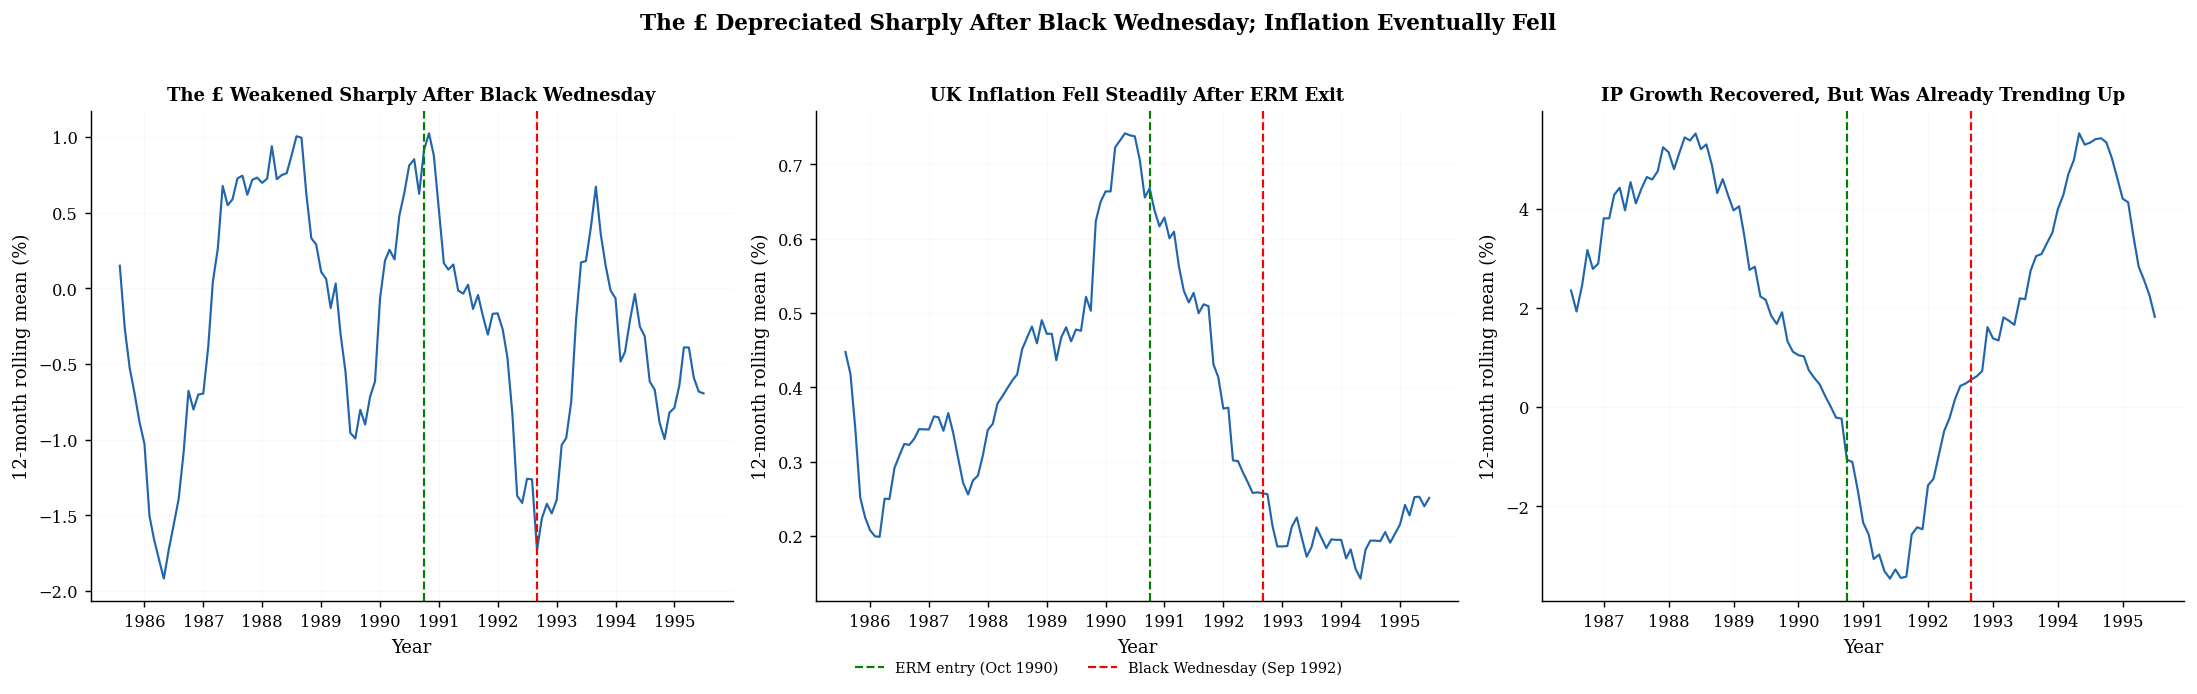

In [30]:
# ─── Rolling 12-month means show level trajectories around ERM events ───
# Look for step changes at ERM entry (Oct 1990) and exit (Sep 1992).
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('The £ Depreciated Sharply After Black Wednesday; Inflation Eventually Fell',
             fontsize=12, fontweight='bold', y=1.02)

for ax, (label, col) in zip(axes, erm_level_vars.items()):
    # 12-month centred rolling mean smooths out seasonal noise and
    # short-term fluctuations, revealing the underlying trend in levels.
    # center=True avoids a lag that would blur the timing of regime shifts.
    rolling = erm.set_index('date')[col].rolling(12, center=True).mean()
    ax.plot(rolling.index, rolling.values, color=C_DE, linewidth=1.2)
    ax.axvline(ERM_JOIN, color='green', linestyle='--', linewidth=1.2)
    ax.axvline(BLACK_WED, color='red', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Year')

    # Informative subplot titles
    lvl_titles = {
        'Real FX Growth DM/£ (%)': 'The £ Weakened Sharply After Black Wednesday',
        'UK Inflation (%)': 'UK Inflation Fell Steadily After ERM Exit',
        'UK 12m IP Growth (%)': 'IP Growth Recovered, But Was Already Trending Up',
    }
    ax.set_title(lvl_titles.get(label, label), fontsize=10)
    ax.set_ylabel('12-month rolling mean (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

erm_event_handles = [
    Line2D([0], [0], color='green', linewidth=1.2, linestyle='--', label='ERM entry (Oct 1990)'),
    Line2D([0], [0], color='red',   linewidth=1.2, linestyle='--', label='Black Wednesday (Sep 1992)'),
]
fig.legend(handles=erm_event_handles, loc='lower center', ncol=2, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

The level trajectories show a clear step-change in the exchange rate
at Black Wednesday, but inflation and IP growth were already trending
before exit. UK inflation was falling throughout (disinflation), and
IP growth was already recovering from mid-1991. This makes it hard to
attribute the post-exit patterns to the regime change itself.

**Analyse the extent of changes in the level of the exchange rate
following Black Wednesday, and any corresponding changes in the levels
of UK inflation and industrial production growth.**

The levels table and rolling mean graphs above show three distinct
patterns following Black Wednesday.

The DM/£ rate fell sharply from 2.81 (Aug 1992) to 2.45 (Oct 1992), a
depreciation of approximately 13% in two months. The rolling mean graph
confirms this was a discrete step change, not a gradual drift.

UK inflation actually *fell* post-ERM (monthly average from 0.43% during
ERM to 0.21% post-ERM), contrary to what a simple exchange rate
pass-through model might predict. The rolling mean graph shows inflation
declining steadily after exit. This likely reflects the shift to
inflation targeting after Black Wednesday, which provided an alternative
nominal anchor once the exchange rate peg was abandoned.

UK industrial production growth improved post-ERM (from −1.7% during to
+3.0% after), but as the rolling mean graph shows, IP growth was already
trending upward before Black Wednesday. The trough of the rolling mean occurred in mid-1991,
over a year before exit. This makes it difficult to
attribute the recovery to the regime change, as opposed to the natural
business cycle or the eventual easing of monetary policy.

In [31]:
# ─── Sensitivity check: reassigning September 1992 to post-ERM ───
# September 1992 blends pre- and post-Black Wednesday data. Check whether
# moving it from "during ERM" to "post-ERM" changes the volatility results.
during_erm_strict = erm[(erm['date'] >= ERM_JOIN) & (erm['date'] < BLACK_WED)]
post_erm_strict   = erm[(erm['date'] >= BLACK_WED) & (erm['date'] <= '1995-12-01')]

print('Sensitivity: September 1992 reassigned to post-ERM')
print(f'{"Variable":<30} {"During (excl Sep 92)":>20} {"Post (incl Sep 92)":>20}')
print('─' * 72)
for label, col in erm_vol_vars.items():
    sd_d = during_erm_strict[col].std()
    sd_p = post_erm_strict[col].std()
    print(f'{label:<30} {sd_d:>20.3f} {sd_p:>20.3f}')
print('\nResults are virtually unchanged; the boundary choice is immaterial.')

Sensitivity: September 1992 reassigned to post-ERM
Variable                       During (excl Sep 92)   Post (incl Sep 92)
────────────────────────────────────────────────────────────────────────
Real FX Growth (DM/£)                         1.352                2.263
UK Inflation                                  0.539                0.320
UK 12-Month IP Growth                         2.914                2.668

Results are virtually unchanged; the boundary choice is immaterial.


#### 5.2.5 Concerns About Drawing Conclusions

**What concerns do you have about drawing conclusions from the analysis
of this particular period?**

Several concerns limit what we can infer from this period.

First, the ERM period is very short (only 24 months), providing few
observations for estimating volatility. The pre- and post-ERM standard
deviations are based on larger samples but still cover periods with many
confounding events.

Second, the UK joined the ERM *because of* its high inflation, and left
*because of* its recession. The regime change is endogenous to the
macroeconomic variables we are studying. Unlike the end of Bretton Woods
(a system-wide collapse affecting all countries simultaneously), the UK's
ERM entry and exit were deliberate policy responses to domestic conditions.

Third, German reunification (an enormous macroeconomic shock) occurred
in the same month as ERM entry. It is impossible to separate the effects
of the exchange rate regime from the effects of reunification on German
monetary policy, European interest rates, and the resulting recession.

Fourth, markets anticipated the devaluation well before Black Wednesday.
The DM/£ graph in Section 5.2.2 shows the exchange rate declining steadily
throughout the ERM period, suggesting the economic effects of the eventual
exit were already being priced in. The "regime change" was therefore
gradual rather than discrete, undermining the regression discontinuity
logic that makes the Bretton Woods analysis in Section 4 so clean.

#### Conclusion

Taken together, the ERM evidence is consistent with the Bretton Woods
finding from Section 4. Exchange rate volatility changed with the regime
(falling under the peg, rising after exit) while macroeconomic volatility
did not move proportionally. This supports the Mussa puzzle. Exchange
rate fluctuations appear largely disconnected from real economic outcomes.

However, the identification here is considerably weaker. The short sample,
endogenous regime changes, and simultaneous reunification shock mean this
episode *supports* the Section 4 conclusion without providing an
independent, clean test of it. The Bretton Woods discontinuity remains the
stronger piece of evidence for answering "Do Exchange Rates Matter?".

## 6. Presenting Your Findings

### Graph 1: The FX Volatility Explosion

This is the graph the Presentation Guidance specifically suggests: "show the
exchange rate being fixed for a long time then the rate suddenly going wild
after it ended."

We adapted the notebook's 2×2 panel (a) into a standalone full-width chart rather than keeping the
2×2 grid, which overwhelms a presentation audience who sees it for 30
seconds. Direct annotations ("Fixed exchange rate" / "Floating exchange
rate") replace the separate legend so the viewer understands what they're
seeing without decoding it (Schwabish 2014). Text is 13–18pt for screen
readability, and labels use plain English since the audience has never
heard of Bretton Woods 30 seconds ago.

**Why nominal, not real?** The nominal exchange rate was genuinely zero (or near-zero)
under Bretton Woods. The peg held it flat except for discrete revaluations. The
real rate fluctuated slightly even under the peg because inflation differed between
countries. For the presentation, the nominal rate shows the fixed-to-floating contrast
more starkly (pre-BW SD of 0.87% vs 0.93% for real), which matters when the
audience has 30 seconds to absorb the chart. The next graph (Graph 2) switches to
real FX for the volatility ratio because the regression analysis in Section 4.4 uses
the real exchange rate, but the audience is told the ratio, not shown the raw SDs,
so the variable switch does not create confusion in practice.

### Graph 2: The Mussa Puzzle

This graph condenses the entire SD table from Section 4.3 into a single visual.
Instead of showing five variables and their SDs in two periods, we show three
post/pre ratios, showing how much did each variable's volatility change?

The design reflects a deliberate choice. **Show the puzzle, not the data.** The
notebook's bar chart shows absolute SD values, which requires the reader to
compare heights mentally. The ratio chart makes the comparison the data itself.
A tall bar means "big change," a short bar near the dashed line means "no
change." The audience sees the answer without doing arithmetic.

We show four ratios (real and nominal FX, inflation, IP) rather than the notebook's five
(which add nominal FX and inflation difference). Four is enough to make the
point; five would add clutter without adding insight for a non-technical audience.

**Why real FX here, not nominal?** The ratio chart uses the real exchange rate
(ratio = 3.1x) rather than the nominal (3.3x). The regression
analysis in Section 4.4 (which the scatter plot on the next slide will show)
uses the real exchange rate as the independent variable. Using real FX in Graph 2
keeps the variable consistent with Graph 3. The difference between 3.1x and 3.3x
is immaterial to the presentation's message. Both say "roughly tripled."

The red-vs-grey colour coding is deliberate. Exchange rates (the variable that
changed) are highlighted, while the macro variables (which didn't) recede into
the background. The audience's eye goes to the tall red bar first, then notices
the short grey bars are barely above the reference line.

### Graph 3: The Scatter Plot

A scatter plot requires more explanation than a bar chart, and the ratio chart
(Graph 2) already shows that macro volatility didn't change.

We kept it because it adds something the ratio chart doesn't. It shows the
relationship at the individual-period level, not just the aggregate. The ratio
chart compares two era-wide averages; the scatter shows every 6-month period
as a separate data point. If there were a non-linear relationship (e.g. macro
volatility increasing only at very high FX volatility), the ratio chart would
miss it but the scatter would reveal it. The flat regression line rules this out.

We show only the inflation regression (one of three from Section 4.4) because
inflation is the most intuitive measure for a non-technical audience. Everyone
understands "the cost of living." We relabelled the legend from "Pre-BW" /
"Post-BW" to "Fixed rate era" / "Floating rate era" and added a plain-English
annotation ("Slope = 0, No relationship") so the audience doesn't need to
interpret the regression line themselves.

**Why only the linear fit, not the quadratic?** The notebook includes both, as
required by the coursework. For the presentation, the quadratic fit would need
explanation ("what is a quadratic fit and why do we care?") that would distract
from the main message. In any case, the quadratic is also essentially flat. It
doesn't reveal a hidden non-linear relationship. Dropping it simplifies the graph
without changing the conclusion. The Presentation Guidance's philosophy applies:
"If there are things that are taking focus away from [the key point], they should be removed."

### Graph 4: The ERM Confirmation

Including a second episode (the UK's ERM) strengthens the presentation
considerably. It shows the Mussa puzzle isn't a one-off German phenomenon
but a general pattern. The Presentation Guidance's suggested timing (2–3
minutes for extensions) supports spending one slide on this.

We chose the rolling SD plot over the SD table because it tells the story
dynamically. The audience can *see* FX volatility dip under the peg and
then spike after Black Wednesday. The shaded green ERM period and direct
annotations ("UK joins ERM" / "Black Wednesday") make the graph self-contained.
No prior knowledge of the ERM is required.

We deliberately did NOT show separate inflation or IP rolling SDs for the ERM
(unlike the notebook, which shows all three). One line is enough to confirm
the pattern; three lines would need explanation and would dilute the message.
The spoken commentary notes that "UK inflation and output volatility barely
changed", but this claim is supported by the notebook analysis (Section 5.2.3),
not shown on the slide, because showing it would require additional graphs
that would clutter a slide whose job is to confirm, not to prove.

**An honest limitation of this graph.** The rolling SD was already declining
*before* the UK joined the ERM. The dip begins around 1989, not October 1990.
The annotation "Peg dampens volatility" on the chart may therefore overstate the
causal role of the peg. It is more accurate to say the peg *coincided with* low
volatility; the pre-entry decline suggests other factors (e.g. expectations of
joining) were also at work. The ERM identification is weaker than the BW discontinuity because the regime change was anticipated and endogenous.

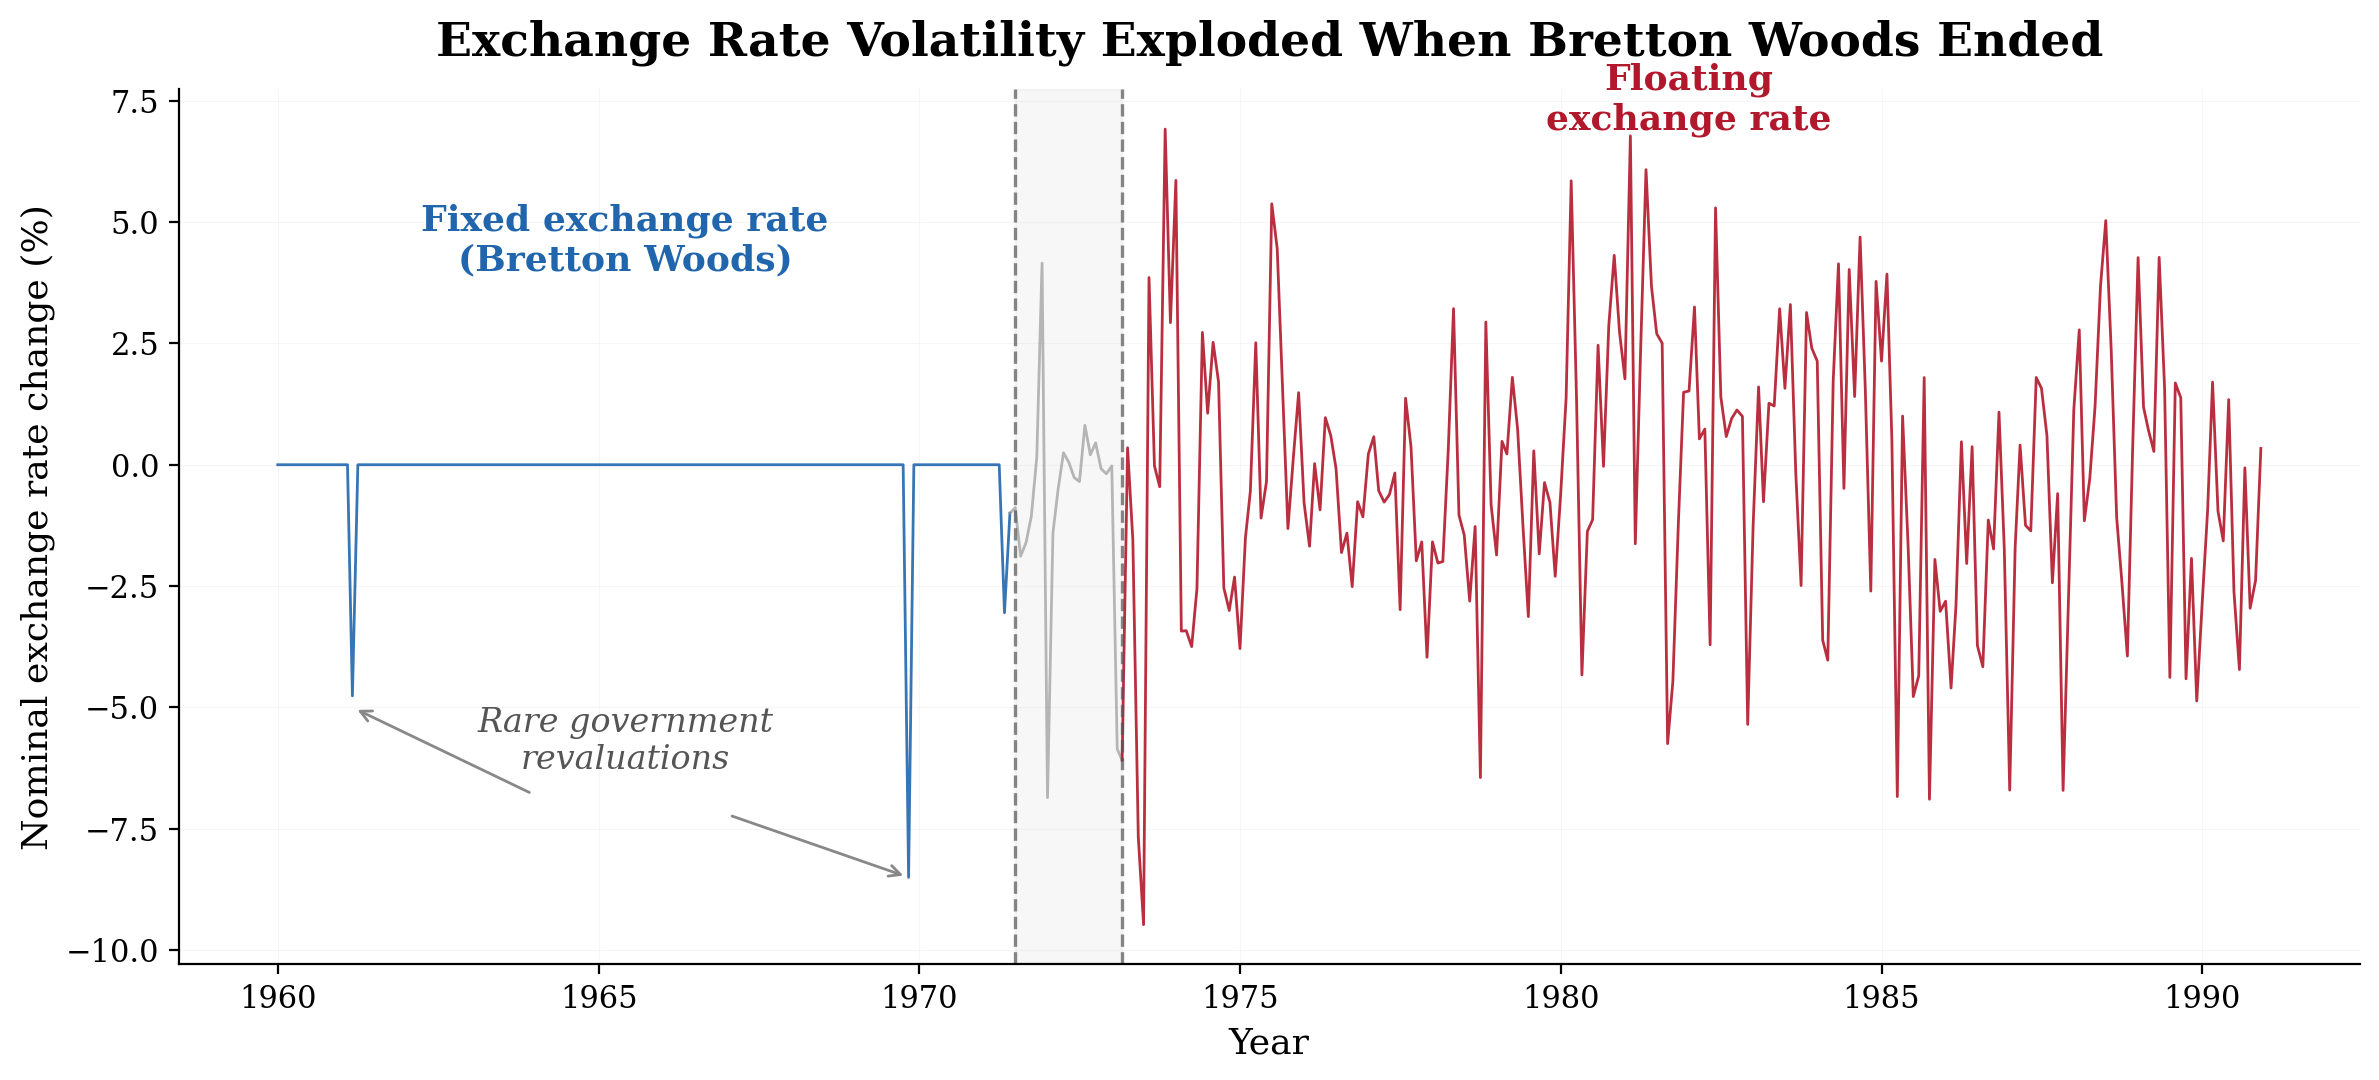

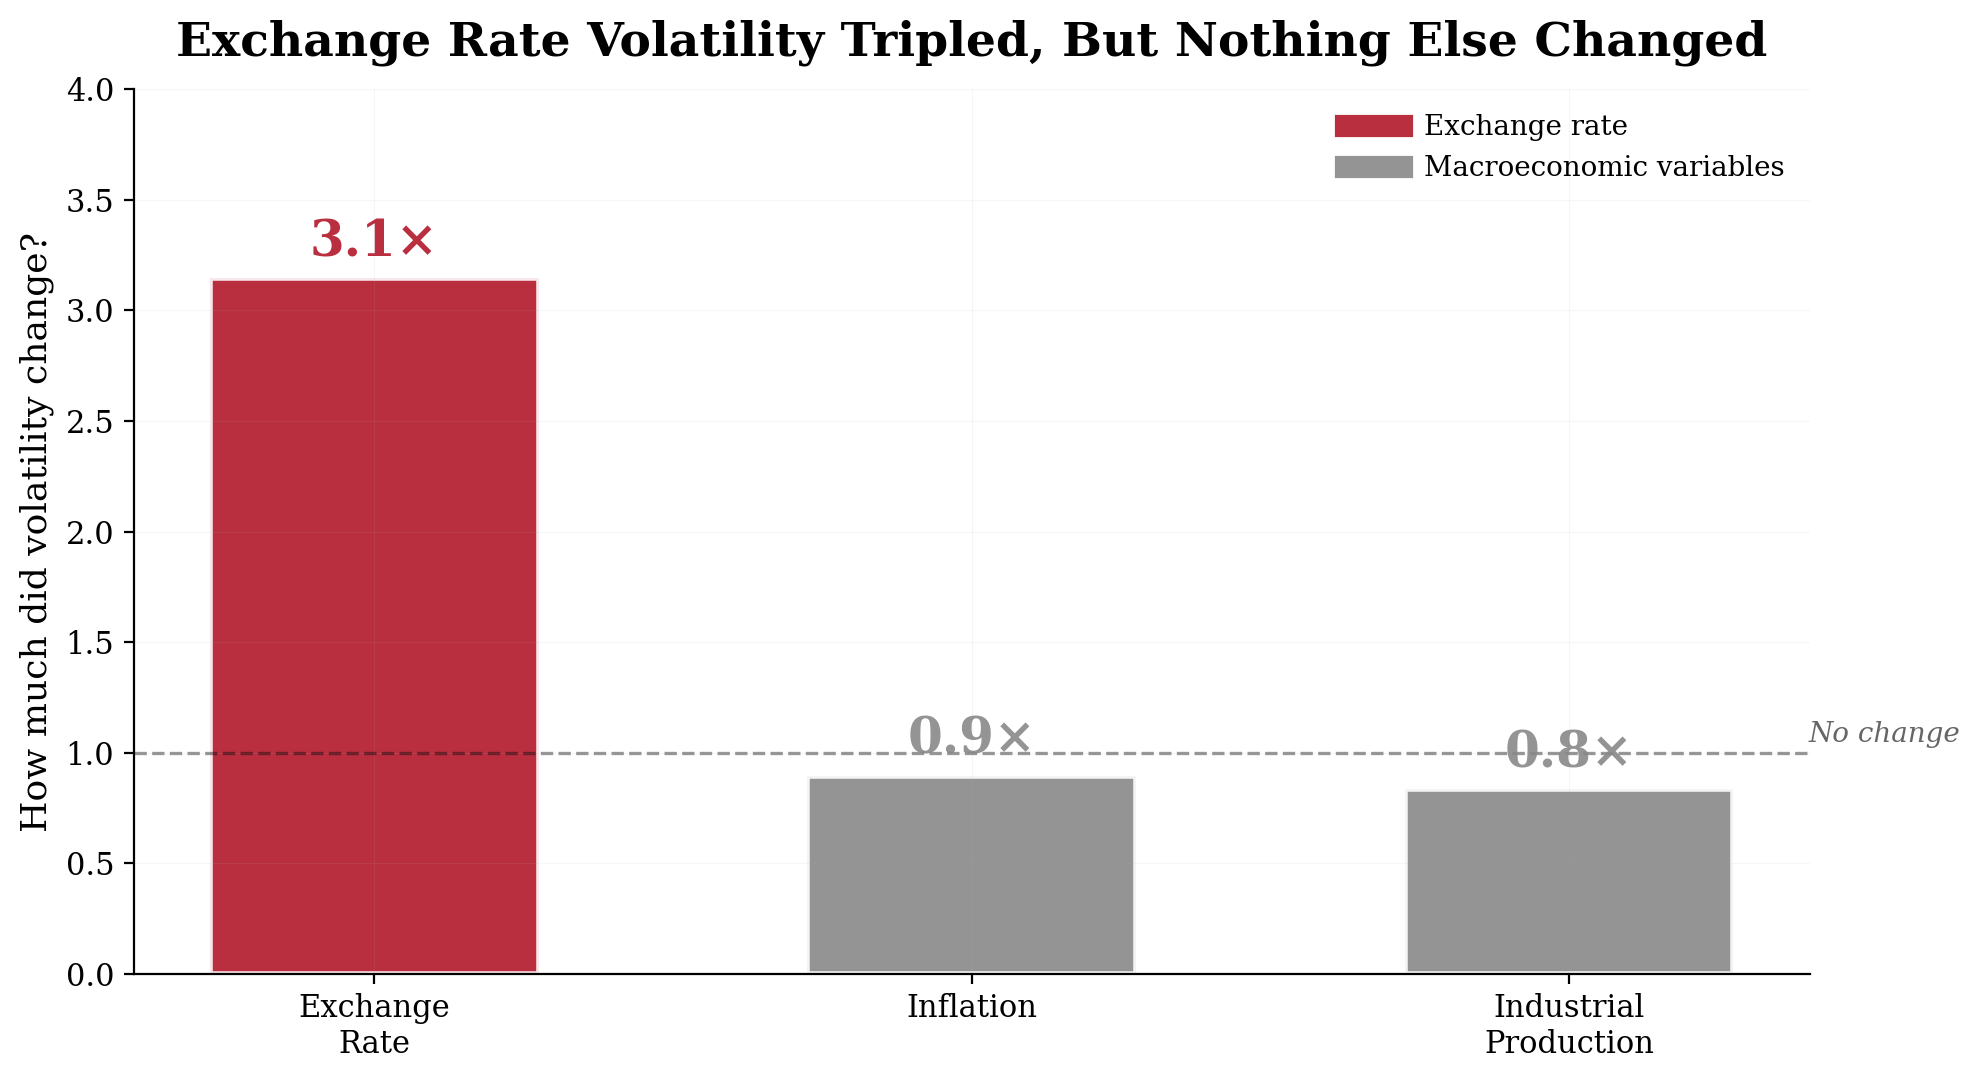

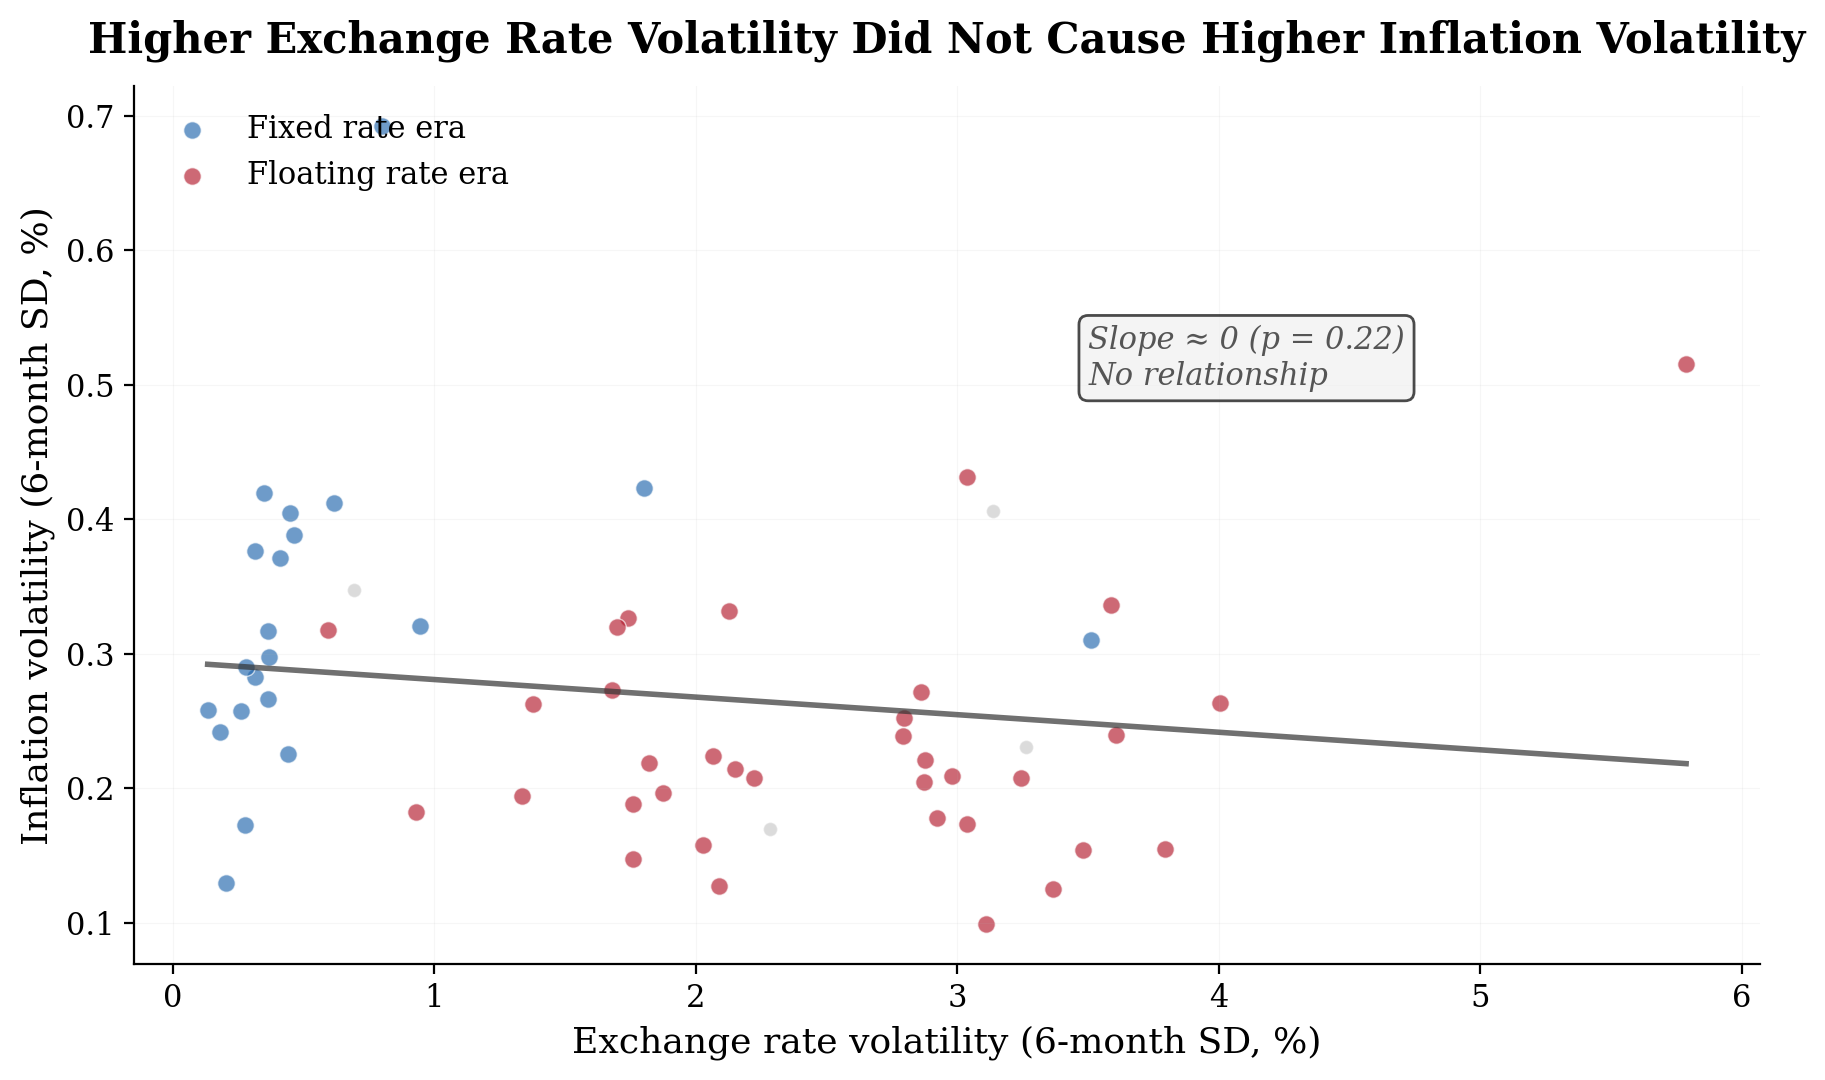

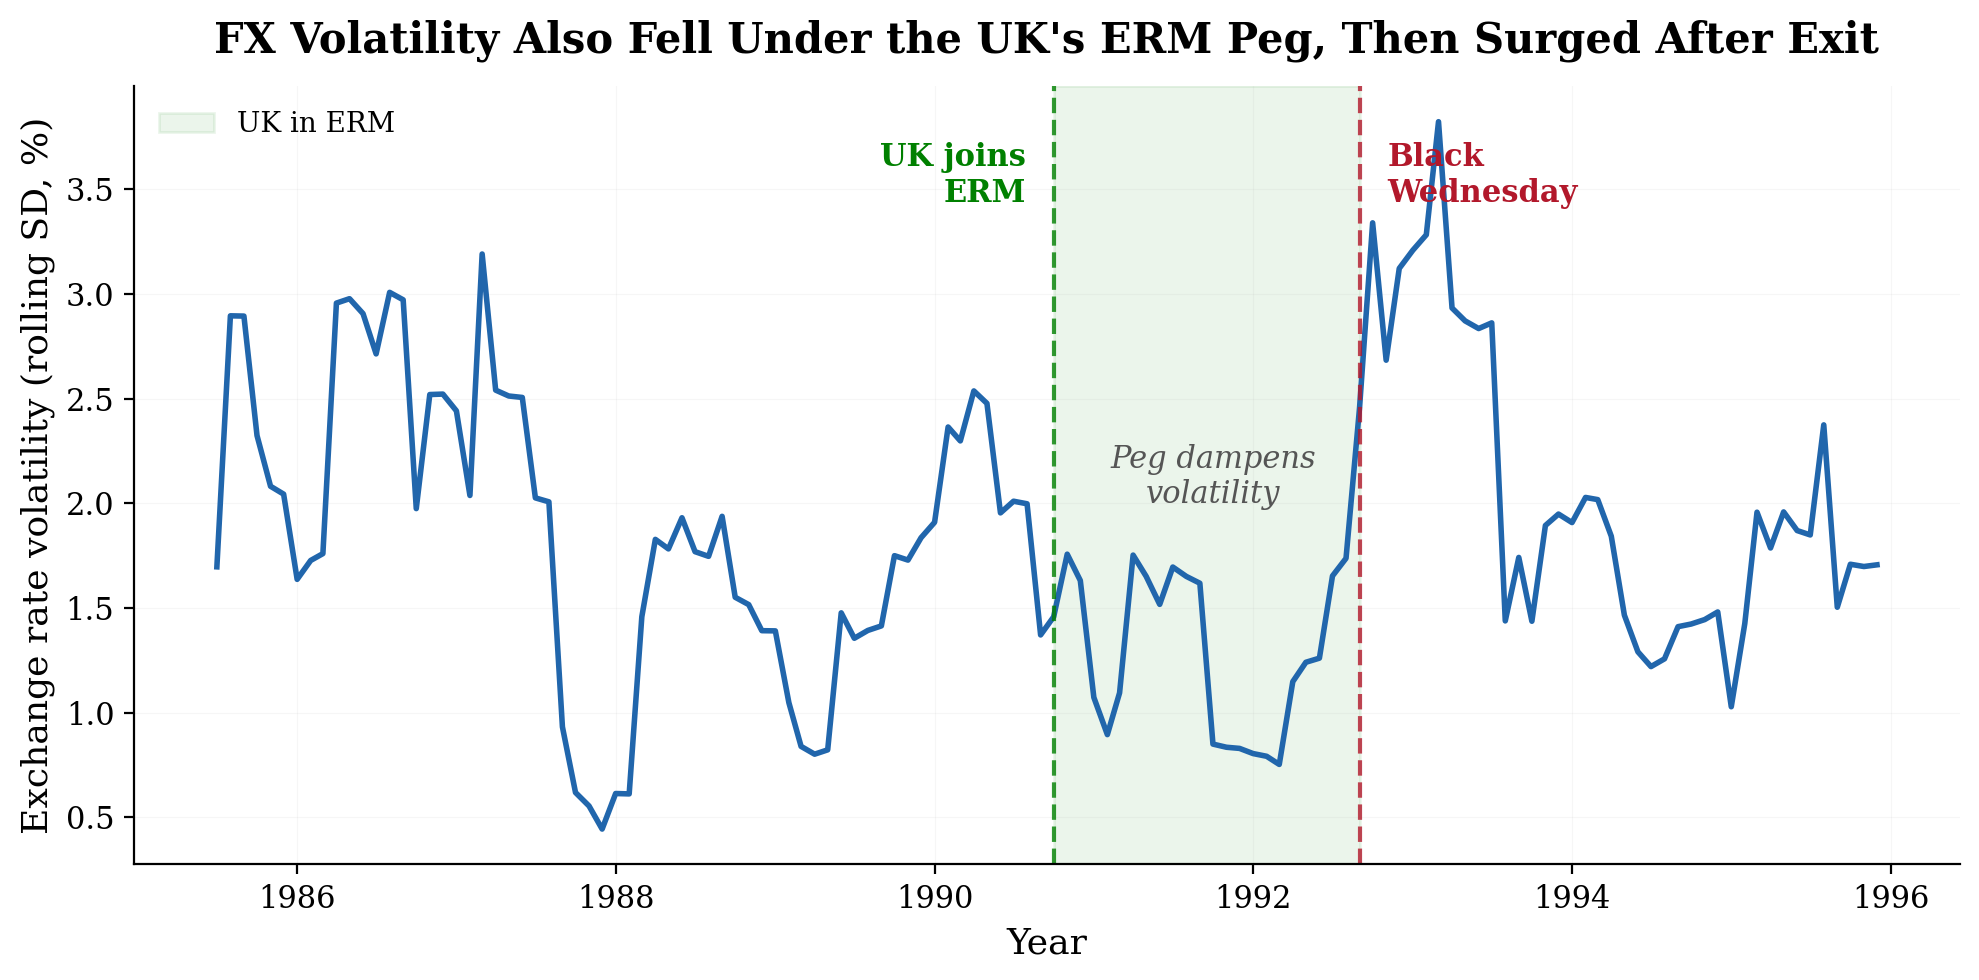

In [32]:
# ═══════════════════════════════════════════════════════════════
# Presentation graphs. adapted from the analysis in Sections 4–5
# for a non-technical audience answering "Do Exchange Rates Matter?"
#
# Key design differences from the notebook graphs:
#   - Standalone single-message graphs (not multi-panel grids)
#   - Larger text (13–18pt) for projection/screen readability
#   - Plain-English labels ("Fixed rate era" not "Pre-BW")
#   - Direct annotations on the chart (Schwabish: integrate text)
#   - Fewer variables per chart. one clear message per slide
# ═══════════════════════════════════════════════════════════════

# ─── Presentation-specific style overrides ───
pres_rc = {
    'figure.dpi': 200,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 16, 'axes.titleweight': 'bold',
    'axes.labelsize': 13, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 11, 'font.family': 'serif',
    'axes.grid': True, 'grid.alpha': 0.10, 'grid.linewidth': 0.4,
}
plt.rcParams.update(pres_rc)


# ─── Graph 1: The "money shot". FX volatility explosion ───
# Line graph version. the flat blue line at zero vs the wild red oscillation
# makes the before/after contrast even more dramatic than bars.
# The line segments are coloured by regime period using the coursework cutoffs:
# blue to June 1971, grey July 1971 – Feb 1973, red from March 1973.
fig, ax = plt.subplots(figsize=(12, 5.5))

pre = plot_df[plot_df['date'] <= '1971-06-01']
trans = plot_df[(plot_df['date'] >= '1971-06-01') & (plot_df['date'] <= '1973-03-01')]
post = plot_df[plot_df['date'] >= '1973-03-01']

ax.plot(pre['date'], pre['g_e_nom'], color=C_PRE, linewidth=1.0, alpha=0.9)
ax.plot(trans['date'], trans['g_e_nom'], color=C_TRANS, linewidth=1.0, alpha=0.7)
ax.plot(post['date'], post['g_e_nom'], color=C_POST, linewidth=1.0, alpha=0.9)

# Shade the transition period
ax.axvspan(pd.Timestamp('1971-07-01'), pd.Timestamp('1973-02-28'),
           alpha=0.06, color='grey', zorder=0)
ax.axvline(pd.Timestamp('1971-07-01'), color='#555', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(pd.Timestamp('1973-03-01'), color='#555', linestyle='--', linewidth=1.2, alpha=0.7)

# Annotations integrated directly on the chart (Schwabish principle 3)
ax.annotate('Fixed exchange rate\n(Bretton Woods)',
            xy=(pd.Timestamp('1965-06-01'), 4.0), fontsize=13,
            color=C_PRE, fontweight='bold', ha='center')
ax.annotate('Floating\nexchange rate',
            xy=(pd.Timestamp('1982-01-01'), 6.9), fontsize=13,
            color=C_POST, fontweight='bold', ha='center')

ax.annotate('Rare government\nrevaluations',
            xy=(pd.Timestamp('1965-06-01'), -5.0),
            fontsize=12, color='#555', style='italic', ha='center', va='top')
ax.annotate('', xy=(pd.Timestamp('1961-03-01'), -5.0),
            xytext=(pd.Timestamp('1964-01-01'), -6.8),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.0))
ax.annotate('', xy=(pd.Timestamp('1969-11-01'), -8.5),
            xytext=(pd.Timestamp('1967-01-01'), -7.2),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.0))

ax.set_ylabel('Nominal exchange rate change (%)', fontsize=13)
ax.set_title('Exchange Rate Volatility Exploded When Bretton Woods Ended',
             fontsize=17, fontweight='bold', pad=12)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year', fontsize=13)
plt.tight_layout()
plt.show()


# ─── Graph 2: The Mussa Puzzle. simplified for non-technical audience ───
# Three bars showing the post/pre volatility ratio for FX, inflation, and IP.
# A tall red bar (3.1×) next to two short grey bars (~1×) tells the whole
# story at a glance: exchange rates changed dramatically, the economy didn't.
fig, ax = plt.subplots(figsize=(10, 5.5))

categories = ['Exchange\nRate', 'Inflation', 'Industrial\nProduction']
ratios = [
    post_bw['g_e_real'].std() / pre_bw['g_e_real'].std(),
    post_bw['inf_de'].std() / pre_bw['inf_de'].std(),
    post_bw['g_ip_12m'].std() / pre_bw['g_ip_12m'].std(),
]
colors = [C_POST, '#888888', '#888888']

bars = ax.bar(categories, ratios, color=colors, width=0.55, alpha=0.9,
              edgecolor='white', linewidth=2)

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{ratio:.1f}×', ha='center', va='bottom', fontsize=18,
            fontweight='bold', color=bar.get_facecolor())

# Dashed reference line at 1.0. "no change" baseline
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.4)
ax.text(2.4, 1.05, 'No change', fontsize=10, color='#666', style='italic')

ax.set_ylabel('How much did volatility change?', fontsize=13)
ax.set_title('Exchange Rate Volatility Tripled, But Nothing Else Changed',
             fontsize=17, fontweight='bold', pad=12)
# Legend for colour meaning
from matplotlib.lines import Line2D
colour_legend = [
    Line2D([0], [0], color=C_POST, linewidth=8, alpha=0.9, label='Exchange rate'),
    Line2D([0], [0], color='#888888', linewidth=8, alpha=0.9, label='Macroeconomic variables'),
]
ax.legend(handles=colour_legend, frameon=False, fontsize=10, loc='upper right')
ax.set_ylim(0, 4.0)

plt.tight_layout()
plt.show()


# ─── Graph 3: Scatter plot. inflation vs FX volatility ───
# Shows the absence of a relationship. Blue dots (fixed era) cluster at
# low FX volatility; red dots (floating) spread to higher FX volatility.
# Both sit at the same height. inflation volatility didn't increase.
# We show only one regression (inflation, the most intuitive for a
# non-technical audience) rather than all three from Section 4.4.
fig, ax = plt.subplots(figsize=(9, 5.5))

for period, colour, label in [('Pre-BW', C_PRE, 'Fixed rate era'),
                               ('Post-BW', C_POST, 'Floating rate era')]:
    mask = reg_df['period'] == period
    ax.scatter(reg_df.loc[mask, 'sd_rer'], reg_df.loc[mask, 'sd_inf_de'],
               c=colour, s=40, alpha=0.65, label=label,
               edgecolors='white', linewidth=0.5)

# Plot transition points without legend entry (unexplained for non-technical audience)
mask_t = reg_df['period'] == 'Transition'
ax.scatter(reg_df.loc[mask_t, 'sd_rer'], reg_df.loc[mask_t, 'sd_inf_de'],
           c=C_TRANS, s=25, alpha=0.35, edgecolors='white', linewidth=0.5)

x = reg_df['sd_rer'].values
y = reg_df['sd_inf_de'].values
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='#333', linewidth=2, alpha=0.7)

ax.set_xlabel('Exchange rate volatility (6-month SD, %)', fontsize=13)
ax.set_ylabel('Inflation volatility (6-month SD, %)', fontsize=13)
ax.set_title('Higher Exchange Rate Volatility Did Not Cause Higher Inflation Volatility',
             fontsize=15, fontweight='bold', pad=12)
ax.legend(frameon=False, fontsize=11, loc='upper left')
ax.annotate(f'Slope ≈ 0 (p = {p:.2f})\nNo relationship',
            xy=(3.5, 0.5), fontsize=11, color='#555', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.7))
plt.tight_layout()
plt.show()


# ─── Graph 4: ERM rolling SD. "the pattern holds elsewhere" ───
# A single line showing FX volatility dipping under the peg and spiking
# after Black Wednesday. The green-shaded ERM period and direct annotations
# tell the story without requiring any prior knowledge of the ERM.
fig, ax = plt.subplots(figsize=(10, 5))

rolling_sd = erm.set_index('date')['g_rer'].rolling(window=6).std()
ax.plot(rolling_sd.index, rolling_sd.values, color=C_PRE, linewidth=2)
ax.axvline(ERM_JOIN, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(BLACK_WED, color=C_POST, linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvspan(ERM_JOIN, BLACK_WED, alpha=0.08, color='green', label='UK in ERM')
ax.legend(frameon=False, fontsize=10, loc='upper left')

ax.annotate('UK joins\nERM', xy=(ERM_JOIN, rolling_sd.max()*0.9),
            fontsize=11, color='green', fontweight='bold', ha='right',
            xytext=(-10, 0), textcoords='offset points')
ax.annotate('Black\nWednesday', xy=(BLACK_WED, rolling_sd.max()*0.9),
            fontsize=11, color=C_POST, fontweight='bold', ha='left',
            xytext=(10, 0), textcoords='offset points')
ax.annotate('Peg dampens\nvolatility',
            xy=(pd.Timestamp('1991-10-01'), 2.0),
            fontsize=11, color='#555', style='italic', ha='center')

ax.set_ylabel('Exchange rate volatility (rolling SD, %)', fontsize=13)
ax.set_title('FX Volatility Also Fell Under the UK\'s ERM Peg, Then Surged After Exit',
             fontsize=15, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year', fontsize=13)
plt.tight_layout()
plt.show()